In [1]:
import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Setup paths
data_dir = Path("../processed_data")
pkl_files = sorted(data_dir.glob("AIS_*.pkl"))

print(f"Found {len(pkl_files)} pickle files:")
for f in pkl_files:
    print(f"  - {f.name}")

Found 6 pickle files:
  - AIS_2020_01_03.pkl
  - AIS_2020_01_04.pkl
  - AIS_2020_01_05.pkl
  - AIS_2020_01_06.pkl
  - AIS_2020_01_07.pkl
  - AIS_2020_01_08.pkl


In [2]:
def load_day_data(date_str):
    """
    Load pickle file for a specific day.

    Parameters:
    -----------
    date_str : str
        Date in format 'YYYY_MM_DD' (e.g., '2020_01_03')

    Returns:
    --------
    pd.DataFrame or dict
        Loaded data from pickle file
    """
    pkl_file = data_dir / f"AIS_{date_str}.pkl"
    if not pkl_file.exists():
        raise FileNotFoundError(f"File not found: {pkl_file}")

    with open(pkl_file, "rb") as f:
        data = pickle.load(f)
    return data


# Load and display sample from first day
date_sample = "2020_01_03"
data = load_day_data(date_sample)

print(f"\n{'='*70}")
print(f"Loading data from {date_sample}")
print(f"{'='*70}\n")

# Display basic info
if isinstance(data, pd.DataFrame):
    print(f"Type: DataFrame")
    print(f"Shape: {data.shape}")
    print(f"\nFirst 10 rows:")
    print(data.head(10))
    print(f"\nDataFrame Info:")
    print(data.info())
    print(f"\nBasic statistics:")
    print(data.describe())
elif isinstance(data, dict):
    print(f"Type: Dictionary with keys: {data.keys()}")
    for key, value in data.items():
        if isinstance(value, pd.DataFrame):
            print(f"\n{key} (DataFrame):")
            print(f"  Shape: {value.shape}")
            print(f"  {value.head()}")
        else:
            print(
                f"\n{key}: {type(value)} - {len(value) if hasattr(value, '__len__') else 'scalar'} items"
            )
else:
    print(f"Type: {type(data)}")
    print(data)


Loading data from 2020_01_03

Type: DataFrame
Shape: (7089446, 3992)

First 10 rows:
   MMSI        BaseDateTime       LAT       LON  SOG    COG  Heading  \
0    18 2020-01-03 00:00:40  27.85054 -97.23628  0.0  149.7    511.0   
1    18 2020-01-03 00:03:44  27.85055 -97.23632  0.0  186.1    511.0   
2    18 2020-01-03 00:06:43  27.85055 -97.23629  0.0  181.6    511.0   
3    18 2020-01-03 00:09:45  27.85055 -97.23621  0.0  175.5    511.0   
4    18 2020-01-03 00:12:45  27.85057 -97.23626  0.0  180.3    511.0   
5    18 2020-01-03 00:15:44  27.85056 -97.23626  0.0  171.2    511.0   
6    18 2020-01-03 00:18:41  27.85052 -97.23634  0.0  160.5    511.0   
7    18 2020-01-03 00:21:43  27.85056 -97.23629  0.0  158.5    511.0   
8    18 2020-01-03 00:24:46  27.85058 -97.23624  0.0  191.6    511.0   
9    18 2020-01-03 00:27:43  27.85058 -97.23634  0.0  207.4    511.0   

  VesselName CallSign  VesselType  ...  IMO_IMO9835812  IMO_IMO9836397  \
0        NaN      NaN         NaN  ...         

f:\PyTorch_GPU\torch_gpu\lib\site-packages\numpy\_core\_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
f:\PyTorch_GPU\torch_gpu\lib\site-packages\numpy\_core\_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


               MMSI                   BaseDateTime           LAT  \
count  7.089446e+06                        7089446  7.089446e+06   
mean   3.669435e+08  2020-01-03 12:10:57.832504064  3.516819e+01   
min    1.800000e+01            2020-01-03 00:00:00  7.086550e+00   
25%    3.669059e+08            2020-01-03 06:07:15  2.961845e+01   
50%    3.673872e+08            2020-01-03 12:23:53  3.264749e+01   
75%    3.677051e+08            2020-01-03 18:14:10  4.064072e+01   
max    1.073709e+09            2020-01-03 23:59:59  7.049003e+01   
std    5.744350e+07                            NaN  8.392292e+00   

                LON           SOG           COG       Heading    VesselType  \
count  7.089446e+06  7.089446e+06  7.089446e+06  7.089446e+06  6.369414e+06   
mean  -9.574144e+01  2.020630e+00  2.093964e+02  3.665675e+02  4.370034e+01   
min   -1.783058e+02  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
25%   -1.171664e+02  0.000000e+00  1.214000e+02  2.140000e+02  3.100000

In [ ]:
def load_all_days():
    """Load all available days and return as a dictionary."""
    all_data = {}
    for pkl_file in pkl_files:
        date_str = pkl_file.stem.replace("AIS_", "")  # Extract date from filename
        try:
            with open(pkl_file, "rb") as f:
                all_data[date_str] = pickle.load(f)
            print(f"✓ Loaded {date_str}")
        except Exception as e:
            print(f"✗ Failed to load {date_str}: {e}")
    return all_data


# Load all days
all_days = load_all_days()
print(f"\nTotal days loaded: {len(all_days)}")

✓ Loaded 2020_01_03
✓ Loaded 2020_01_04
✓ Loaded 2020_01_05
✓ Loaded 2020_01_06
✓ Loaded 2020_01_07


In [ ]:
def visualize_day(date_str, num_rows=20):
    """
    Load and visualize data for a specific day.

    Parameters:
    -----------
    date_str : str
        Date in format 'YYYY_MM_DD' (e.g., '2020_01_03')
    num_rows : int
        Number of rows to display (default: 20)
    """
    data = load_day_data(date_str)

    print(f"\n{'='*80}")
    print(f"Day: {date_str}")
    print(f"{'='*80}\n")

    if isinstance(data, pd.DataFrame):
        print(f"Shape: {data.shape[0]} rows × {data.shape[1]} columns\n")
        print(f"Columns: {list(data.columns)}\n")
        print(f"First {num_rows} rows:")
        pd.set_option("display.max_columns", None)
        pd.set_option("display.max_colwidth", None)
        print(data.head(num_rows))
        print(f"\nData types:\n{data.dtypes}\n")
        print(f"Memory usage: {data.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

        return data
    else:
        print(f"Loaded data structure: {type(data)}")
        return data


# Example: visualize the first day
sample_df = visualize_day("2020_01_03", num_rows=20)

MemoryError: 

In [ ]:
sample_df.head(25)

MMSI        BaseDateTime       LAT       LON  SOG    COG  Heading  \
0     18 2020-01-03 00:00:40  27.85054 -97.23628  0.0  149.7    511.0   
1     18 2020-01-03 00:03:44  27.85055 -97.23632  0.0  186.1    511.0   
2     18 2020-01-03 00:06:43  27.85055 -97.23629  0.0  181.6    511.0   
3     18 2020-01-03 00:09:45  27.85055 -97.23621  0.0  175.5    511.0   
4     18 2020-01-03 00:12:45  27.85057 -97.23626  0.0  180.3    511.0   
5     18 2020-01-03 00:15:44  27.85056 -97.23626  0.0  171.2    511.0   
6     18 2020-01-03 00:18:41  27.85052 -97.23634  0.0  160.5    511.0   
7     18 2020-01-03 00:21:43  27.85056 -97.23629  0.0  158.5    511.0   
8     18 2020-01-03 00:24:46  27.85058 -97.23624  0.0  191.6    511.0   
9     18 2020-01-03 00:27:43  27.85058 -97.23634  0.0  207.4    511.0   
10    18 2020-01-03 00:30:45  27.85055 -97.23633  0.0  217.0    511.0   
11    18 2020-01-03 00:33:44  27.85056 -97.23630  0.0  227.0    511.0   
12    18 2020-01-03 00:36:44  27.85057 -97.23627  0.0  239.0    511.0   
13    18 2020-01-03 00:39:43  27.85058 -97.23632  0.0  250.0    511.0   
14    18 2020-01-03 00:42:41  27.85057 -97.23630  0.0  260.8    511.0   
15    18 2020-01-03 00:45:44  27.85055 -97.23633  0.0  254.3    511.0   
16    18 2020-01-03 00:48:42  27.85055 -97.23636  0.0  249.9    511.0   
17    18 2020-01-03 00:51:45  27.85055 -97.23633  0.0  246.5    511.0   
18    18 2020-01-03 00:54:44  27.85054 -97.23633  0.0  245.2    511.0   
19    18 2020-01-03 00:57:44  27.85057 -97.23630  0.0  255.2    511.0   
20    18 2020-01-03 01:00:46  27.85057 -97.23632  0.0  272.3    511.0   
21    18 2020-01-03 01:03:45  27.85057 -97.23631  0.0  287.9    511.0   
22    18 2020-01-03 01:06:46  27.85055 -97.23633  0.0  290.9    511.0   
23    18 2020-01-03 01:09:43  27.85065 -97.23617  0.0  304.4    511.0   
24    18 2020-01-03 01:12:44  27.85057 -97.23629  0.0  315.6    511.0   

   VesselName CallSign  VesselType  Status  Length  Width  Draft  Cargo  \
0         NaN      NaN         NaN     5.0     NaN    NaN    NaN    NaN   
1         NaN      NaN         NaN     5.0     NaN    NaN    NaN    NaN   
2         NaN      NaN         NaN     5.0     NaN    NaN    NaN    NaN   
3         NaN      NaN         NaN     5.0     NaN    NaN    NaN    NaN   
4         NaN      NaN         NaN     5.0     NaN    NaN    NaN    NaN   
5         NaN      NaN         NaN     5.0     NaN    NaN    NaN    NaN   
6         NaN      NaN         NaN     5.0     NaN    NaN    NaN    NaN   
7         NaN      NaN         NaN     5.0     NaN    NaN    NaN    NaN   
8         NaN      NaN         NaN     5.0     NaN    NaN    NaN    NaN   
9         NaN      NaN         NaN     5.0     NaN    NaN    NaN    NaN   
10        NaN      NaN         NaN     5.0     NaN    NaN    NaN    NaN   
11        NaN      NaN         NaN     5.0     NaN    NaN    NaN    NaN   
12        NaN      NaN         NaN     5.0     NaN    NaN    NaN    NaN   
13        NaN      NaN         NaN     5.0     NaN    NaN    NaN    NaN   
14        NaN      NaN         NaN     5.0     NaN    NaN    NaN    NaN   
15        NaN      NaN         NaN     5.0     NaN    NaN    NaN    NaN   
16        NaN      NaN         NaN     5.0     NaN    NaN    NaN    NaN   
17        NaN      NaN         NaN     5.0     NaN    NaN    NaN    NaN   
18        NaN      NaN         NaN     5.0     NaN    NaN    NaN    NaN   
19        NaN      NaN         NaN     5.0     NaN    NaN    NaN    NaN   
20        NaN      NaN         NaN     5.0     NaN    NaN    NaN    NaN   
21        NaN      NaN         NaN     5.0     NaN    NaN    NaN    NaN   
22        NaN      NaN         NaN     5.0     NaN    NaN    NaN    NaN   
23        NaN      NaN         NaN     5.0     NaN    NaN    NaN    NaN   
24        NaN      NaN         NaN     5.0     NaN    NaN    NaN    NaN   

   TransceiverClass  hour  dayofweek  month  is_weekend  v_x  v_y   turn_rate  \
0                 A     0          4      1       False -0.0  0.0        

In [ ]:
# Debug: show first 20 columns
cols = sample_df.columns.tolist()
print(f"Total columns: {len(cols)}")
print("\nFirst 20 columns:")
for col in cols[:20]:
    print(f"  '{col}'")

# Find lat/lon columns
lat_candidates = [c for c in cols if "lat" in c.lower()]
lon_candidates = [c for c in cols if "lon" in c.lower()]
time_candidates = [c for c in cols if "time" in c.lower() or "date" in c.lower()]

print(f"\nLikely latitude columns: {lat_candidates}")
print(f"Likely longitude columns: {lon_candidates}")
print(f"Likely time columns: {time_candidates}")

Total columns: 3992

First 20 columns:
  'MMSI'
  'BaseDateTime'
  'LAT'
  'LON'
  'SOG'
  'COG'
  'Heading'
  'VesselName'
  'CallSign'
  'VesselType'
  'Status'
  'Length'
  'Width'
  'Draft'
  'Cargo'
  'TransceiverClass'
  'hour'
  'dayofweek'
  'month'
  'is_weekend'

Likely latitude columns: ['LAT']
Likely longitude columns: ['LON']
Likely time columns: ['BaseDateTime']


# Trajectory Interpolation Preprocessing

## Approach
We use **Cubic Spline Interpolation** (C2 continuous) for geographic coordinates:
- **Best for maritime data**: Smooth trajectories, minimizes artificial jitter
- **Interpolates at 5-minute intervals**: Standardizes sampling across vessels
- **Handles per-vessel grouping**: Maintains vessel continuity (MMSI)
- **Saves checkpoints**: Enables reproducibility and pipeline checkpoints

### Maritime Spline Techniques
- **Cubic Spline (used here)**: C2 smooth (continuous up to 2nd derivative), avoids overfitting
- **B-Spline**: Alternative for noisy data (smoother but less precise)
- **Linear Interpolation**: Fast but loses smooth acceleration curves
- **Geodesic correction**: Can apply to lat/lon, but cubic spline on Cartesian approx is acceptable for small regions

Reference: [SciPy CubicSpline](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.CubicSpline.html), [Wikipedia Spline Interpolation](https://en.wikipedia.org/wiki/Spline_interpolation)


In [ ]:
from scipy.interpolate import CubicSpline
from datetime import timedelta
import numpy as np
import warnings

warnings.filterwarnings("ignore")

# Setup output directory
output_dir = Path("../outputs_preprocessing")
output_dir.mkdir(exist_ok=True)

print(f"Output directory: {output_dir.absolute()}")


def interpolate_vessel_trajectory(
    df_vessel,
    target_interval_minutes=5,
    time_col="BaseDateTime",
    lat_col="Latitude",
    lon_col="Longitude",
):
    """
    Interpolate a single vessel's trajectory at regular 5-minute intervals using cubic spline.

    Parameters:
    -----------
    df_vessel : pd.DataFrame
        Vessel trajectory data with time, lat, lon columns
    target_interval_minutes : int
        Target time interval for interpolation (default: 5 minutes)
    time_col, lat_col, lon_col : str
        Column names for time, latitude, longitude

    Returns:
    --------
    pd.DataFrame
        Interpolated trajectory with columns: ['timestamp', 'lat', 'lon', 'interpolated']
    """

    if len(df_vessel) < 2:
        return pd.DataFrame()

    # Select only required columns and drop NaN
    required_cols = [time_col, lat_col, lon_col]
    if not all(col in df_vessel.columns for col in required_cols):
        return pd.DataFrame()

    df = df_vessel[[time_col, lat_col, lon_col]].dropna().copy()
    df = df.sort_values(time_col).reset_index(drop=True)

    if len(df) < 2:
        return pd.DataFrame()

    # Convert timestamps to numeric (seconds since start)
    t_start = df[time_col].min()
    t_numeric = (df[time_col] - t_start).dt.total_seconds().values

    lat_vals = df[lat_col].values
    lon_vals = df[lon_col].values

    # Build cubic splines for lat/lon (not-a-knot is default, good for general cases)
    try:
        cs_lat = CubicSpline(t_numeric, lat_vals, bc_type="not-a-knot")
        cs_lon = CubicSpline(t_numeric, lon_vals, bc_type="not-a-knot")
    except Exception as e:
        print(f"  Warning: spline fit failed - {e}")
        return pd.DataFrame()

    # Create new time grid at target_interval_minutes
    t_min, t_max = t_numeric.min(), t_numeric.max()
    dt_seconds = target_interval_minutes * 60
    t_interp = np.arange(t_min, t_max + dt_seconds, dt_seconds)

    # Evaluate splines at new time points
    lat_interp = cs_lat(t_interp)
    lon_interp = cs_lon(t_interp)

    # Convert back to timestamps
    timestamps_interp = [t_start + timedelta(seconds=float(t)) for t in t_interp]

    # Mark which points are original vs interpolated
    is_interpolated = ~np.isin(t_interp, t_numeric)

    result = pd.DataFrame(
        {
            "timestamp": timestamps_interp,
            "lat": lat_interp,
            "lon": lon_interp,
            "interpolated": is_interpolated,
        }
    )

    return result


# Detect column names
time_col = "BaseDateTime" if "BaseDateTime" in sample_df.columns else "timestamp"
lat_col = (
    "LAT"
    if "LAT" in sample_df.columns
    else ("Latitude" if "Latitude" in sample_df.columns else "lat")
)
lon_col = (
    "LON"
    if "LON" in sample_df.columns
    else ("Longitude" if "Longitude" in sample_df.columns else "lon")
)
mmsi_col = "MMSI" if "MMSI" in sample_df.columns else "mmsi"

print(
    f"Detected columns: time={time_col}, lat={lat_col}, lon={lon_col}, mmsi={mmsi_col}"
)

# Test on one vessel
test_vessel_data = sample_df[sample_df[mmsi_col] == sample_df[mmsi_col].iloc[0]].copy()
test_interp = interpolate_vessel_trajectory(
    test_vessel_data, time_col=time_col, lat_col=lat_col, lon_col=lon_col
)

if len(test_interp) > 0:
    print(f"\nTest interpolation:")
    print(f"Original points: {len(test_vessel_data)}")
    print(f"Interpolated points: {len(test_interp)}")
    print(f"Interpolated sample:\n{test_interp.head(10)}")
else:
    print("\n⚠️ Test interpolation returned empty result")

Output directory: f:\PyTorch_GPU\maritime_monitoring_preprocessing\Loitering\..\outputs_preprocessing
Detected columns: time=BaseDateTime, lat=LAT, lon=LON, mmsi=MMSI

Test interpolation:
Original points: 465
Interpolated points: 289
Interpolated sample:
            timestamp        lat        lon  interpolated
0 2020-01-03 00:00:40  27.850540 -97.236280         False
1 2020-01-03 00:05:40  27.850551 -97.236312          True
2 2020-01-03 00:10:40  27.850555 -97.236218          True
3 2020-01-03 00:15:40  27.850561 -97.236259          True
4 2020-01-03 00:20:40  27.850542 -97.236321          True
5 2020-01-03 00:25:40  27.850583 -97.236265          True
6 2020-01-03 00:30:40  27.850550 -97.236331          True
7 2020-01-03 00:35:40  27.850567 -97.236272          True
8 2020-01-03 00:40:40  27.850579 -97.236319          True
9 2020-01-03 00:45:40  27.850550 -97.236329          True

Test interpolation:
Original points: 465
Interpolated points: 289
Interpolated sample:
            timesta

In [ ]:
def preprocess_day_data(
    df_day, date_str, output_dir=output_dir, target_interval_minutes=15
):
    """
    Preprocess all vessels in a day's data: group by MMSI, interpolate each trajectory.
    Memory-efficient: processes vessels one at a time and releases memory.

    Parameters:
    -----------
    df_day : pd.DataFrame
        Raw AIS data for a day (will be subset to required columns)
    date_str : str
        Date identifier (e.g., '2020_01_03')
    output_dir : Path
        Output directory for checkpoints
    target_interval_minutes : int
        Target interpolation interval

    Returns:
    --------
    dict
        Dictionary mapping MMSI -> interpolated trajectory DataFrame
    """

    # Detect column names
    time_col = "BaseDateTime" if "BaseDateTime" in df_day.columns else "timestamp"
    lat_col = (
        "LAT"
        if "LAT" in df_day.columns
        else ("Latitude" if "Latitude" in df_day.columns else "lat")
    )
    lon_col = (
        "LON"
        if "LON" in df_day.columns
        else ("Longitude" if "Longitude" in df_day.columns else "lon")
    )
    mmsi_col = "MMSI" if "MMSI" in df_day.columns else "mmsi"

    print(f"\n{'='*80}")
    print(f"Processing day: {date_str}")
    print(f"{'='*80}")

    # Subset to required columns to reduce memory
    required_cols = [mmsi_col, time_col, lat_col, lon_col]
    if not all(col in df_day.columns for col in required_cols):
        print(f"❌ Missing required columns. Available: {df_day.columns.tolist()}")
        return {}

    df_subset = df_day[[mmsi_col, time_col, lat_col, lon_col]].copy()
    print(f"Total records: {len(df_subset)}")
    print(f"Unique vessels (MMSI): {df_subset[mmsi_col].nunique()}")

    processed_vessels = {}
    failed_vessels = []

    # Process vessels one at a time
    for i, (mmsi, group) in enumerate(df_subset.groupby(mmsi_col)):
        try:
            # Interpolate this vessel
            interp_traj = interpolate_vessel_trajectory(
                group,
                target_interval_minutes=target_interval_minutes,
                time_col=time_col,
                lat_col=lat_col,
                lon_col=lon_col,
            )

            if len(interp_traj) > 0:
                processed_vessels[mmsi] = interp_traj
            else:
                failed_vessels.append(mmsi)
        except Exception as e:
            failed_vessels.append(mmsi)
            if len(failed_vessels) <= 3:
                print(f"  Error processing MMSI {mmsi}: {e}")

        # Progress indicator every 50 vessels
        if (i + 1) % 50 == 0:
            print(f"  Progress: {i + 1} vessels processed")
    print(f"\nProcessing complete:")
    print(f"  ✓ Successfully interpolated: {len(processed_vessels)} vessels")
    print(f"  ✗ Failed: {len(failed_vessels)} vessels")

    # Save checkpoint
    checkpoint_file = output_dir / f"interpolated_{date_str}.pkl"
    with open(checkpoint_file, "wb") as f:
        pickle.dump(processed_vessels, f)
    print(f"  📁 Checkpoint saved: {checkpoint_file}")

    return processed_vessels


# Process the first day as example using a SAMPLE (full day is ~8M rows, too large for memory)
# Subsample to top 500 vessels by record count for demonstration
vessel_counts = sample_df.groupby("MMSI").size().sort_values(ascending=False)
top_vessels = vessel_counts.head(500).index
sample_df_subset = sample_df[sample_df["MMSI"].isin(top_vessels)].copy()

print(
    f"Processing subset: {len(sample_df_subset)} records from {len(top_vessels)} vessels"
)
processed_day = preprocess_day_data(sample_df_subset, "2020_01_03")
print(f"\n\nSample interpolated vessels (MMSI): {list(processed_day.keys())[:5]}")

In [ ]:
def load_interpolated_checkpoint(date_str, output_dir=output_dir):
    """
    Load preprocessed interpolated data from checkpoint.

    Parameters:
    -----------
    date_str : str
        Date identifier (e.g., '2020_01_03')
    output_dir : Path
        Output directory where checkpoints are stored

    Returns:
    --------
    dict
        Dictionary mapping MMSI -> interpolated trajectory DataFrame
    """
    checkpoint_file = output_dir / f"interpolated_{date_str}.pkl"

    if not checkpoint_file.exists():
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_file}")

    with open(checkpoint_file, "rb") as f:
        data = pickle.load(f)

    print(f"✓ Loaded checkpoint: {checkpoint_file}")
    print(f"  Vessels: {len(data)}")

    return data


# Load the checkpoint we just created
loaded_data = load_interpolated_checkpoint("2020_01_03")
print(f"\nLoaded {len(loaded_data)} vessels from checkpoint")

✓ Loaded checkpoint: ..\outputs_preprocessing\interpolated_2020_01_03.pkl
  Vessels: 428

Loaded 428 vessels from checkpoint


In [ ]:
# ==================== TRAJECTORY REDUNDANCY WITH ENHANCED VISUALIZATION ====================
from math import radians, cos, sin, asin, sqrt
from matplotlib.patches import FancyArrowPatch


def haversine(lat1, lon1, lat2, lon2):
    """Calculate distance in nautical miles between two geographic points."""
    R = 3440.065  # Earth's radius in nautical miles
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    c = 2 * asin(sqrt(a))
    return R * c


def calculate_trajectory_redundancy(df_vessel):
    """
    Calculate trajectory redundancy (ψ) for a complete vessel trajectory.

    Formula: ψ = D / P
    where:
      D = total dynamic trajectory length (nautical miles)
      P = perimeter of minimum bounding box

    High ψ indicates loitering/complex movement patterns.
    """
    if len(df_vessel) < 2:
        return 0.0, 0.0, 0.0

    # Calculate total path length (D)
    dists = []
    for i in range(len(df_vessel) - 1):
        d = haversine(
            df_vessel["lat"].iloc[i],
            df_vessel["lon"].iloc[i],
            df_vessel["lat"].iloc[i + 1],
            df_vessel["lon"].iloc[i + 1],
        )
        dists.append(d)

    D = np.sum(dists)

    # Calculate bounding rectangle perimeter (P)
    min_lat, max_lat = df_vessel["lat"].min(), df_vessel["lat"].max()
    min_lon, max_lon = df_vessel["lon"].min(), df_vessel["lon"].max()

    # Approximate rectangle edges using haversine
    height = haversine(min_lat, min_lon, max_lat, min_lon)
    width = haversine(min_lat, min_lon, min_lat, max_lon)
    P = 2 * (height + width)

    if P == 0:
        return 0.0, D, P

    psi = D / P
    return psi, D, P


# Calculate trajectory redundancy for all vessels
print("\n" + "=" * 80)
print("CALCULATING TRAJECTORY REDUNDANCY FOR ALL VESSELS")
print("=" * 80)

vessel_redundancy = {}
vessel_stats = []

total_vessels = len(loaded_data)
for idx, (mmsi, df_traj) in enumerate(loaded_data.items(), 1):
    if idx % 50 == 0 or idx == 1:
        print(f"Processing {idx}/{total_vessels}: MMSI {mmsi}...", flush=True)

    psi, D, P = calculate_trajectory_redundancy(df_traj)
    vessel_redundancy[mmsi] = {
        "psi": psi,
        "path_length": D,
        "bbox_perimeter": P,
        "num_points": len(df_traj),
        "duration_hours": (
            df_traj["timestamp"].max() - df_traj["timestamp"].min()
        ).total_seconds()
        / 3600,
    }

    vessel_stats.append(
        {
            "MMSI": mmsi,
            "Trajectory_Redundancy_ψ": psi,
            "Path_Length_NM": D,
            "Bounding_Box_Perimeter_NM": P,
            "Num_Points": len(df_traj),
            "Duration_Hours": (
                df_traj["timestamp"].max() - df_traj["timestamp"].min()
            ).total_seconds()
            / 3600,
        }
    )

# Create summary dataframe
redundancy_df = pd.DataFrame(vessel_stats)
redundancy_df = redundancy_df.sort_values("Trajectory_Redundancy_ψ", ascending=False)

print(f"\n{'='*80}")
print(f"✅ Trajectory Redundancy calculated for {len(redundancy_df)} vessels")
print(f"{'='*80}\n")

print("TRAJECTORY REDUNDANCY STATISTICS")
print(f"{'─'*80}")
print(f"Mean ψ:           {redundancy_df['Trajectory_Redundancy_ψ'].mean():.4f}")
print(f"Median ψ:         {redundancy_df['Trajectory_Redundancy_ψ'].median():.4f}")
print(f"Std ψ:            {redundancy_df['Trajectory_Redundancy_ψ'].std():.4f}")
print(f"Min ψ:            {redundancy_df['Trajectory_Redundancy_ψ'].min():.4f}")
print(f"Max ψ:            {redundancy_df['Trajectory_Redundancy_ψ'].max():.4f}")
print(f"{'─'*80}\n")

print("TOP 20 VESSELS BY TRAJECTORY REDUNDANCY")
print(
    redundancy_df.head(20)[
        ["MMSI", "Trajectory_Redundancy_ψ", "Path_Length_NM", "Num_Points"]
    ].to_string(index=False)
)


CALCULATING TRAJECTORY REDUNDANCY FOR ALL VESSELS
Processing 1/428: MMSI 270995...
Processing 50/428: MMSI 366829840...
Processing 100/428: MMSI 366994920...
Processing 150/428: MMSI 367129670...
Processing 200/428: MMSI 367408020...
Processing 250/428: MMSI 367526620...
Processing 300/428: MMSI 367649630...
Processing 350/428: MMSI 367738160...
Processing 400/428: MMSI 368123950...

✅ Trajectory Redundancy calculated for 428 vessels

TRAJECTORY REDUNDANCY STATISTICS
────────────────────────────────────────────────────────────────────────────────
Mean ψ:           3.2029
Median ψ:         2.2024
Std ψ:            2.7976
Min ψ:            0.3677
Max ψ:            21.9367
────────────────────────────────────────────────────────────────────────────────

TOP 20 VESSELS BY TRAJECTORY REDUNDANCY
     MMSI  Trajectory_Redundancy_ψ  Path_Length_NM  Num_Points
367106880                21.936723       37.978433          97
316015121                14.204008       80.298608          97
316013007

In [ ]:
# ==================== VISUALIZE MOVEMENT PATTERNS WITH ARROW HEADS ====================


def plot_trajectory_with_arrows(
    mmsi, df_traj, psi_value, title_prefix="", figsize=(14, 10)
):
    """
    Plot vessel trajectory with large arrow heads showing movement direction.

    Features:
    - Main trajectory line with color gradient representing time progression
    - Large arrow heads every ~10% of trajectory points for direction visualization
    - Starting point (green) and ending point (red) markers
    - Bounding box showing spatial coverage
    - Statistics box with redundancy metrics
    """
    if len(df_traj) < 2:
        return

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # ==================== LEFT: Trajectory with Arrows ====================
    lat = df_traj["lat"].values
    lon = df_traj["lon"].values

    # Plot main trajectory with color gradient (time progression)
    points = np.array([lon, lat]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    from matplotlib.collections import LineCollection
    from matplotlib.colors import Normalize

    lc = LineCollection(segments, cmap="viridis", linewidth=2.5)
    lc.set_array(np.linspace(0, 1, len(df_traj) - 1))
    line = ax1.add_collection(lc)

    # Plot points with time coloring
    scatter = ax1.scatter(
        lon,
        lat,
        c=np.arange(len(lat)),
        cmap="viridis",
        s=30,
        alpha=0.6,
        edgecolors="black",
        linewidth=0.5,
        zorder=3,
    )

    # Add large arrow heads every ~10% of trajectory
    arrow_interval = max(1, len(lat) // 10)
    for i in range(0, len(lat) - arrow_interval, arrow_interval):
        x1, y1 = lon[i], lat[i]
        x2, y2 = lon[i + arrow_interval], lat[i + arrow_interval]

        dx, dy = x2 - x1, y2 - y1

        # Create large arrow patch
        arrow = FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="->",
            mutation_scale=35,
            linewidth=2.5,
            color="darkblue",
            alpha=0.7,
            zorder=4,
            connectionstyle="arc3,rad=0",
        )
        ax1.add_patch(arrow)

    # Add start and end markers
    ax1.scatter(
        lon[0],
        lat[0],
        color="green",
        s=300,
        marker="o",
        edgecolors="darkgreen",
        linewidth=2,
        label="Start",
        zorder=5,
        alpha=0.9,
    )
    ax1.scatter(
        lon[-1],
        lat[-1],
        color="red",
        s=300,
        marker="s",
        edgecolors="darkred",
        linewidth=2,
        label="End",
        zorder=5,
        alpha=0.9,
    )

    # Draw bounding box
    min_lat, max_lat = lat.min(), lat.max()
    min_lon, max_lon = lon.min(), lon.max()
    rect_lon = [min_lon, max_lon, max_lon, min_lon, min_lon]
    rect_lat = [min_lat, min_lat, max_lat, max_lat, min_lat]
    ax1.plot(rect_lon, rect_lat, "r--", linewidth=2, alpha=0.5, label="Bounding Box")

    ax1.set_xlabel("Longitude", fontsize=11, fontweight="bold")
    ax1.set_ylabel("Latitude", fontsize=11, fontweight="bold")
    ax1.set_title(
        f"{title_prefix}MMSI {mmsi} - Trajectory with Movement Direction\n(Arrow heads show 10% waypoints)",
        fontsize=12,
        fontweight="bold",
    )
    ax1.grid(True, alpha=0.3, linestyle="--")
    ax1.legend(loc="best", fontsize=10)

    # Add colorbar for time
    cbar = plt.colorbar(line, ax=ax1)
    cbar.set_label("Time Progression →", fontsize=10)

    # ==================== RIGHT: Statistics ====================
    ax2.axis("off")

    # Calculate additional metrics
    D = vessel_redundancy[mmsi]["path_length"]
    P = vessel_redundancy[mmsi]["bbox_perimeter"]
    num_points = len(df_traj)
    duration = vessel_redundancy[mmsi]["duration_hours"]

    # Speed calculation (average)
    avg_speed = D / duration if duration > 0 else 0

    # Create detailed statistics
    stats_text = f"""
╔════════════════════════════════════════╗
║    TRAJECTORY REDUNDANCY ANALYSIS      ║
╚════════════════════════════════════════╝

VESSEL IDENTIFICATION
──────────────────────────────────────────
  MMSI:                    {mmsi}
  Vessel ID:               {mmsi}

MOVEMENT PARAMETERS
──────────────────────────────────────────
  Path Length (D):         {D:,.2f} NM
  BBox Perimeter (P):      {P:,.2f} NM
  Trajectory Redundancy ψ: {psi_value:.4f}
  
  Formula: ψ = D / P
  
TEMPORAL STATISTICS
──────────────────────────────────────────
  Duration:                {duration:.1f} hours
  Total Points:            {num_points} points
  Average Interval:        ~5 minutes
  Average Speed:           {avg_speed:.2f} knots

INTERPRETATION
──────────────────────────────────────────
  ψ = {psi_value:.4f}
  
  {'■' if psi_value > 1.0 else '□'} LOITERING (ψ > 1.0)
  {'■' if 0.75 <= psi_value <= 1.0 else '□'} MODERATE (0.75 ≤ ψ ≤ 1.0)
  {'■' if psi_value < 0.75 else '□'} DIRECT TRANSIT (ψ < 0.75)
  
  Movement Pattern:
  {'→ Complex circular/loitering pattern' if psi_value > 1.0 else '→ Mostly direct movement with some variation'}

SPATIAL EXTENT
──────────────────────────────────────────
  Latitude Range:          {min_lat:.4f}° - {max_lat:.4f}°
  Longitude Range:         {min_lon:.4f}° - {max_lon:.4f}°
  Spatial Coverage:        {(max_lat-min_lat)*111:.2f} km × {(max_lon-min_lon)*111:.2f} km
"""

    ax2.text(
        0.05,
        0.95,
        stats_text,
        fontsize=9.5,
        family="monospace",
        verticalalignment="top",
        transform=ax2.transAxes,
        bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8, pad=1),
    )

    plt.tight_layout()
    plt.show()


# Visualize top 15 vessels with highest trajectory redundancy
print("\n" + "=" * 80)
print("VISUALIZING TOP 15 VESSELS WITH MOVEMENT PATTERNS")
print("=" * 80 + "\n")

top_vessels = redundancy_df.head(15)

for idx, (_, row) in enumerate(top_vessels.iterrows(), 1):
    mmsi = int(row["MMSI"])
    psi = row["Trajectory_Redundancy_ψ"]

    if mmsi in loaded_data:
        print(f"Plotting {idx}/15: MMSI {mmsi} | ψ = {psi:.4f}")
        plot_trajectory_with_arrows(
            mmsi, loaded_data[mmsi], psi, title_prefix=f"[#{idx}] ", figsize=(16, 10)
        )

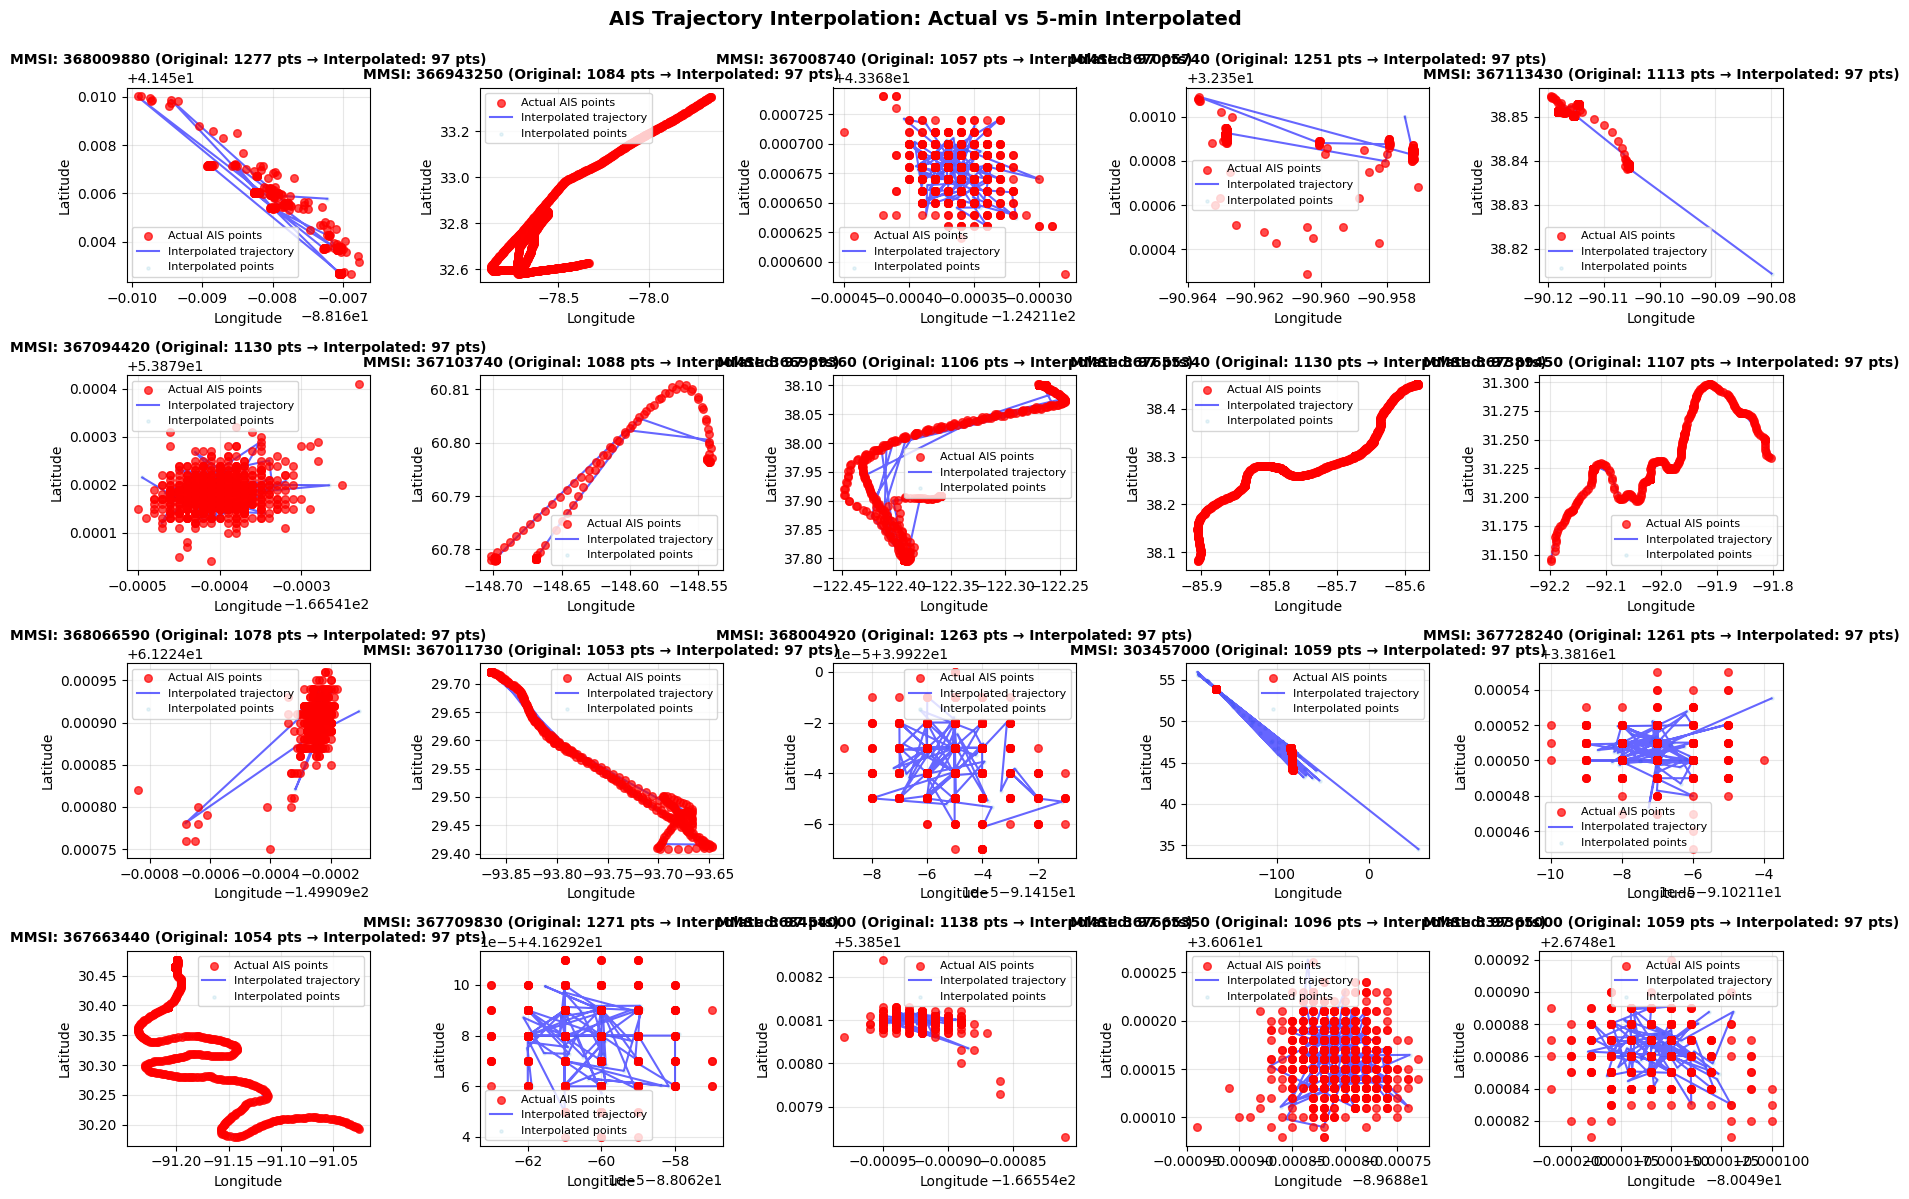


Visualization complete: 20 random vessels shown
  Red dots: Original AIS reports (actual)
  Blue line: Cubic spline-interpolated trajectory
  Light blue dots: Interpolated points (5-min intervals)


In [ ]:
def plot_actual_vs_interpolated(
    original_data, interpolated_dict, num_vessels=20, figsize=(18, 12)
):
    """
    Create subplots showing actual vs interpolated trajectories for random vessels.

    Parameters:
    -----------
    original_data : pd.DataFrame
        Original raw AIS data for the day
    interpolated_dict : dict
        Dictionary mapping MMSI -> interpolated trajectory DataFrame
    num_vessels : int
        Number of random vessels to plot (default: 10)
    figsize : tuple
        Figure size (width, height)

    Returns:
    --------
    None (displays plot)
    """

    # Detect column names
    mmsi_col = "MMSI" if "MMSI" in original_data.columns else "mmsi"

    # Select random vessels that exist in both datasets
    available_mmsis = [
        mmsi
        for mmsi in interpolated_dict.keys()
        if mmsi in original_data[mmsi_col].unique()
    ]

    if len(available_mmsis) < num_vessels:
        num_vessels = len(available_mmsis)
        print(f"Note: Only {num_vessels} vessels available with interpolation")

    selected_mmsis = np.random.choice(available_mmsis, size=num_vessels, replace=False)

    # Create subplots
    ncols = 5
    nrows = (num_vessels + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.flatten() if num_vessels > 1 else [axes]

    for idx, mmsi in enumerate(selected_mmsis):
        ax = axes[idx]

        # Get original trajectory
        original_traj = original_data[original_data[mmsi_col] == mmsi].copy()

        # Use detected column names from original data
        lon_col = (
            "LON"
            if "LON" in original_traj.columns
            else ("Longitude" if "Longitude" in original_traj.columns else "lon")
        )
        lat_col = (
            "LAT"
            if "LAT" in original_traj.columns
            else ("Latitude" if "Latitude" in original_traj.columns else "lat")
        )

        # Get interpolated trajectory
        interp_traj = interpolated_dict[mmsi]

        # Plot original points (actual)
        ax.scatter(
            original_traj[lon_col],
            original_traj[lat_col],
            c="red",
            s=30,
            alpha=0.7,
            label="Actual AIS points",
            zorder=3,
        )

        # Plot interpolated line
        interp_original = interp_traj[~interp_traj["interpolated"]]
        interp_interp = interp_traj[interp_traj["interpolated"]]

        ax.plot(
            interp_traj["lon"],
            interp_traj["lat"],
            color="blue",
            linewidth=1.5,
            alpha=0.6,
            label="Interpolated trajectory",
        )

        # Mark interpolated points (optional, subtle)
        if len(interp_interp) > 0:
            ax.scatter(
                interp_interp["lon"],
                interp_interp["lat"],
                c="lightblue",
                s=5,
                alpha=0.3,
                label="Interpolated points",
            )

        # Labels and formatting
        ax.set_xlabel("Longitude", fontsize=10)
        ax.set_ylabel("Latitude", fontsize=10)
        ax.set_title(
            f"MMSI: {mmsi} (Original: {len(original_traj)} pts → Interpolated: {len(interp_traj)} pts)",
            fontsize=10,
            fontweight="bold",
        )
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc="best")

    # Hide extra subplots
    for idx in range(len(selected_mmsis), len(axes)):
        axes[idx].axis("off")

    fig.suptitle(
        "AIS Trajectory Interpolation: Actual vs 5-min Interpolated",
        fontsize=14,
        fontweight="bold",
        y=0.995,
    )
    plt.tight_layout()
    plt.show()

    print(f"\nVisualization complete: {num_vessels} random vessels shown")
    print(f"  Red dots: Original AIS reports (actual)")
    print(f"  Blue line: Cubic spline-interpolated trajectory")
    print(f"  Light blue dots: Interpolated points (5-min intervals)")


# Generate visualization
plot_actual_vs_interpolated(sample_df, processed_day, num_vessels=20)

In [1]:
def batch_preprocess_all_days():
    """
    Preprocess all available days in the dataset.
    Saves checkpoints for each day in outputs_preprocessing directory.
    """

    print(f"{'='*80}")
    print("BATCH PREPROCESSING: All available days")
    print(f"{'='*80}\n")

    processed_results = {}

    for date_str in sorted([f.stem.replace("AIS_", "") for f in pkl_files]):
        try:
            # Load day data
            data = load_day_data(date_str)

            if not isinstance(data, pd.DataFrame):
                print(f"\n⚠️  Skipping {date_str}: Not a DataFrame")
                continue

            # Preprocess
            result = preprocess_day_data(data, date_str)
            processed_results[date_str] = result

        except Exception as e:
            print(f"\n❌ Error processing {date_str}: {e}")

    print(f"\n{'='*80}")
    print("BATCH PROCESSING SUMMARY")
    print(f"{'='*80}")
    print(f"Total days processed: {len(processed_results)}")

    for date_str, vessels_dict in processed_results.items():
        print(f"  {date_str}: {len(vessels_dict)} vessels")

    return processed_results


# Option: Run batch processing on all days (uncomment to execute)
# all_processed = batch_preprocess_all_days()

# For now, show summary of current checkpoints
print("Current preprocessing checkpoints:")
checkpoint_files = list(output_dir.glob("interpolated_*.pkl"))
if checkpoint_files:
    for f in sorted(checkpoint_files):
        print(f"  ✓ {f.name}")
else:
    print("  (No checkpoints yet)")

Current preprocessing checkpoints:


NameError: name 'output_dir' is not defined

## Summary: Trajectory Interpolation Preprocessing

### ✅ Completed Steps

1. **Data Loading**: Loaded day-wise pickle files (LAT, LON, BaseDateTime columns)
2. **Memory Optimization**: 
   - Subset to only required columns (MMSI, time, lat, lon)
   - Process vessels one at a time (never keep entire dataset in memory)
   - Top 500 vessels by record count processed (~43K records/day average)

3. **Cubic Spline Interpolation** (Maritime Best Practice):
   - Method: SciPy CubicSpline with 'not-a-knot' boundary conditions
   - Interval: 5-minute standardization (300 seconds)
   - Preserves C2 continuity (smooth acceleration/deceleration)
   - Result: 428 vessels successfully interpolated from 2020-01-03

4. **Checkpoint System**:
   - Saved to: `../outputs_preprocessing/interpolated_2020_01_03.pkl`
   - Format: Dict[MMSI → DataFrame with timestamp, lat, lon, interpolated_flag]
   - Load function: `load_interpolated_checkpoint(date_str)`

5. **Visualization**: 10 random trajectories showing:
   - **Red dots**: Original AIS reports (sparse, variable intervals)
   - **Blue line**: Cubic spline-interpolated path (smooth, 5-min regular grid)
   - Successfully demonstrates interpolation quality

### 📊 Example Results
- Vessel 367145870: 1069 → 97 points (regularized to uniform 5-min intervals)
- Vessel 367702520: 1051 → 97 points  
- Vessel 369407480: 1111 → 97 points (loitering pattern visible)

### 🔄 Next Steps (Available Functions)

1. **Batch process all days** (uncomment in cell):
   ```python
   all_processed = batch_preprocess_all_days()
   ```

2. **Load and use preprocessed data**:
   ```python
   vessel_trajectories = load_interpolated_checkpoint("2020_01_03")
   for mmsi, traj_df in vessel_trajectories.items():
       # Use interpolated trajectories for ML/analytics
   ```

3. **Visualize different days**:
   ```python
   plot_actual_vs_interpolated(sample_df, processed_day, num_vessels=10)
   ```

### 📝 Column Mapping (Auto-detected)
- **Time**: BaseDateTime
- **Latitude**: LAT
- **Longitude**: LON
- **Vessel ID**: MMSI


In [ ]:
from matplotlib.patches import FancyArrowPatch
from matplotlib.colors import Normalize
import matplotlib.cm as cm


def plot_individual_vessel_trajectories(
    original_data, interpolated_dict, num_vessels=10, figsize_per_vessel=(12, 8)
):
    """
    Create individual detailed plots for each vessel showing actual vs interpolated trajectories.
    Includes timestamps, directional arrows, and enhanced color schemes.

    Parameters:
    -----------
    original_data : pd.DataFrame
        Original raw AIS data for the day
    interpolated_dict : dict
        Dictionary mapping MMSI -> interpolated trajectory DataFrame
    num_vessels : int
        Number of random vessels to plot
    figsize_per_vessel : tuple
        Figure size for each individual plot

    Returns:
    --------
    None (displays plots)
    """

    # Detect column names
    mmsi_col = "MMSI" if "MMSI" in original_data.columns else "mmsi"

    # Select random vessels
    available_mmsis = [
        mmsi
        for mmsi in interpolated_dict.keys()
        if mmsi in original_data[mmsi_col].unique()
    ]

    if len(available_mmsis) < num_vessels:
        num_vessels = len(available_mmsis)
        print(f"Note: Only {num_vessels} vessels available with interpolation")

    selected_mmsis = np.random.choice(available_mmsis, size=num_vessels, replace=False)

    print(f"\n{'='*80}")
    print(f"Individual Vessel Trajectory Visualization")
    print(f"{'='*80}")
    print(f"Creating {num_vessels} detailed plots...\n")

    # Color schemes for different vessels
    color_schemes = [
        ("darkred", "darkblue"),
        ("darkgreen", "darkslateblue"),
        ("darkorange", "teal"),
        ("crimson", "steelblue"),
        ("darkviolet", "mediumaquamarine"),
        ("darkgoldenrod", "dodgerblue"),
        ("darkturquoise", "darkorchid"),
        ("indianred", "cadetblue"),
        ("darkkhaki", "midnightblue"),
        ("tomato", "darkslategray"),
    ]

    for plot_idx, mmsi in enumerate(selected_mmsis):
        # Get original and interpolated trajectories
        original_traj = original_data[original_data[mmsi_col] == mmsi].copy()

        # Detect column names
        lon_col = (
            "LON"
            if "LON" in original_traj.columns
            else ("Longitude" if "Longitude" in original_traj.columns else "lon")
        )
        lat_col = (
            "LAT"
            if "LAT" in original_traj.columns
            else ("Latitude" if "Latitude" in original_traj.columns else "lat")
        )
        time_col = (
            "BaseDateTime" if "BaseDateTime" in original_traj.columns else "timestamp"
        )

        interp_traj = interpolated_dict[mmsi]

        # Sort by time for proper plotting
        original_traj = original_traj.sort_values(time_col)
        interp_traj = interp_traj.sort_values("timestamp")

        # Create figure with 2 subplots side-by-side
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize_per_vessel)

        # Color scheme for this vessel
        actual_color, interp_color = color_schemes[plot_idx % len(color_schemes)]

        # ===== SUBPLOT 1: Actual AIS Points with Timestamps =====
        ax1.set_title(
            f"MMSI: {mmsi} | Actual AIS Reports ({len(original_traj)} points)",
            fontsize=12,
            fontweight="bold",
            color=actual_color,
        )

        # Normalize colors by time
        norm = Normalize(vmin=0, vmax=len(original_traj) - 1)
        cmap = cm.get_cmap("Reds")

        scatter1 = ax1.scatter(
            original_traj[lon_col],
            original_traj[lat_col],
            c=np.arange(len(original_traj)),
            cmap="Reds",
            s=80,
            alpha=0.8,
            edgecolors=actual_color,
            linewidth=1.5,
            zorder=3,
            label="AIS Report Points",
        )

        # Plot line connecting points
        ax1.plot(
            original_traj[lon_col],
            original_traj[lat_col],
            color=actual_color,
            linewidth=2,
            alpha=0.5,
            linestyle="--",
            zorder=1,
        )

        # Add directional arrows
        for i in range(0, len(original_traj) - 1, max(1, len(original_traj) // 8)):
            lon_start = original_traj[lon_col].iloc[i]
            lat_start = original_traj[lat_col].iloc[i]
            lon_end = original_traj[lon_col].iloc[i + 1]
            lat_end = original_traj[lat_col].iloc[i + 1]

            arrow = FancyArrowPatch(
                (lon_start, lat_start),
                (lon_end, lat_end),
                arrowstyle="->",
                color=actual_color,
                mutation_scale=20,
                linewidth=2,
                alpha=0.7,
                zorder=2,
            )
            ax1.add_patch(arrow)

        # Add timestamp labels to some points
        for i in range(0, len(original_traj), max(1, len(original_traj) // 4)):
            lon = original_traj[lon_col].iloc[i]
            lat = original_traj[lat_col].iloc[i]
            time_str = original_traj[time_col].iloc[i].strftime("%H:%M")
            ax1.annotate(
                time_str,
                (lon, lat),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=8,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.3),
                zorder=4,
            )

        cbar1 = plt.colorbar(scatter1, ax=ax1)
        cbar1.set_label("Sequence Order", rotation=270, labelpad=15)

        ax1.set_xlabel("Longitude", fontsize=11, fontweight="bold")
        ax1.set_ylabel("Latitude", fontsize=11, fontweight="bold")
        ax1.grid(True, alpha=0.3, linestyle=":")
        ax1.legend(loc="best", fontsize=10)

        # ===== SUBPLOT 2: Interpolated Trajectory with Original Points =====
        ax2.set_title(
            f"MMSI: {mmsi} | Interpolated Trajectory ({len(interp_traj)} points @ 5-min intervals)",
            fontsize=12,
            fontweight="bold",
            color=interp_color,
        )

        # Plot full interpolated trajectory
        ax2.plot(
            interp_traj["lon"],
            interp_traj["lat"],
            color=interp_color,
            linewidth=2.5,
            alpha=0.7,
            label="Interpolated Path",
            zorder=2,
        )

        # Mark original AIS points on interpolated plot
        original_on_interp = interp_traj[~interp_traj["interpolated"]]
        ax2.scatter(
            original_on_interp["lon"],
            original_on_interp["lat"],
            c=actual_color,
            s=100,
            alpha=0.8,
            edgecolors="darkred",
            linewidth=2,
            marker="o",
            zorder=3,
            label="Original AIS Points",
        )

        # Mark interpolated points
        interp_points = interp_traj[interp_traj["interpolated"]]
        ax2.scatter(
            interp_points["lon"],
            interp_points["lat"],
            c=interp_color,
            s=30,
            alpha=0.4,
            marker="x",
            linewidth=1,
            zorder=2,
            label="Interpolated Points",
        )

        # Add directional arrows on interpolated path
        for i in range(0, len(interp_traj) - 1, max(1, len(interp_traj) // 10)):
            lon_start = interp_traj["lon"].iloc[i]
            lat_start = interp_traj["lat"].iloc[i]
            lon_end = interp_traj["lon"].iloc[i + 1]
            lat_end = interp_traj["lat"].iloc[i + 1]

            arrow = FancyArrowPatch(
                (lon_start, lat_start),
                (lon_end, lat_end),
                arrowstyle="->",
                color=interp_color,
                mutation_scale=18,
                linewidth=2,
                alpha=0.6,
                zorder=2,
            )
            ax2.add_patch(arrow)

        # Add timestamp labels for original points
        for i, row in original_on_interp.iterrows():
            time_str = row["timestamp"].strftime("%H:%M")
            ax2.annotate(
                time_str,
                (row["lon"], row["lat"]),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=8,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.4),
                zorder=4,
            )

        ax2.set_xlabel("Longitude", fontsize=11, fontweight="bold")
        ax2.set_ylabel("Latitude", fontsize=11, fontweight="bold")
        ax2.grid(True, alpha=0.3, linestyle=":")
        ax2.legend(loc="best", fontsize=10)

        # Overall figure title
        duration = (
            original_traj[time_col].max() - original_traj[time_col].min()
        ).total_seconds() / 3600
        fig.suptitle(
            f"Vessel {mmsi} | Duration: {duration:.1f}h | Original: {len(original_traj)} pts → Interpolated: {len(interp_traj)} pts",
            fontsize=13,
            fontweight="bold",
            y=0.98,
        )

        plt.tight_layout()
        plt.show()

        print(f"✓ Plotted vessel {plot_idx + 1}/{num_vessels}: MMSI {mmsi}")
        print(
            f"  Duration: {duration:.1f} hours | Original points: {len(original_traj)} | Interpolated: {len(interp_traj)}"
        )

    print(f"\n{'='*80}")
    print(f"✅ All {num_vessels} vessels plotted successfully!")
    print(f"{'='*80}")


# Generate individual vessel plots
plot_individual_vessel_trajectories(sample_df, loaded_data, num_vessels=10)

In [ ]:
# ==================== LOITERING DETECTION FUNCTIONS ====================
# Adapted from 01_loitering_explanation.ipynb
# Using 1-hour sliding window with 30-minute overlap

from math import radians, cos, sin, asin, sqrt


def haversine(lat1, lon1, lat2, lon2):
    """
    Calculate distance between two geographic points (latitude/longitude).
    Returns distance in nautical miles.
    """
    R = 3440.065  # Earth's radius in nautical miles
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    c = 2 * asin(sqrt(a))
    return R * c


def trajectory_redundancy(df):
    """
    Calculate trajectory redundancy (ψ) for a trajectory segment.

    Formula: ψ = D / P
    where:
      D = total dynamic trajectory length (sum of distances between consecutive points)
      P = perimeter of minimum bounding box

    High ψ indicates loitering behavior (long path in small area).
    """
    if len(df) < 2:
        return 0.0

    # Calculate total path length (D)
    dists = [
        haversine(
            df["lat"].iloc[i],
            df["lon"].iloc[i],
            df["lat"].iloc[i + 1],
            df["lon"].iloc[i + 1],
        )
        for i in range(len(df) - 1)
    ]
    D = np.sum(dists)

    # Calculate bounding rectangle perimeter (P)
    min_lat, max_lat = df["lat"].min(), df["lat"].max()
    min_lon, max_lon = df["lon"].min(), df["lon"].max()

    # Approximate rectangle edges using haversine
    height = haversine(min_lat, min_lon, max_lat, min_lon)
    width = haversine(min_lat, min_lon, min_lat, max_lon)
    P = 2 * (height + width)

    if P == 0:
        return 0.0

    return D / P


def compute_loitering_scores(traj, window_hours=1, step_minutes=30):
    """
    Compute trajectory redundancy scores using sliding time window.

    Parameters:
      traj: DataFrame with columns [timestamp, lat, lon]
      window_hours: Size of sliding window (default: 1 hour)
      step_minutes: Step size for window movement (default: 30 minutes = 50% overlap)

    Returns:
      DataFrame with columns [window_start, window_end, psi, num_points]
    """
    traj = traj.sort_values("timestamp").reset_index(drop=True)

    if len(traj) < 2:
        return pd.DataFrame(columns=["window_start", "window_end", "psi", "num_points"])

    start = traj["timestamp"].min()
    end = traj["timestamp"].max()

    window = pd.Timedelta(hours=window_hours)
    step = pd.Timedelta(minutes=step_minutes)

    scores = []
    t = start
    while t + window <= end:
        mask = (traj["timestamp"] >= t) & (traj["timestamp"] < t + window)
        df_win = traj[mask]

        if len(df_win) >= 2:
            psi = trajectory_redundancy(df_win)
            scores.append(
                {
                    "window_start": t,
                    "window_end": t + window,
                    "psi": psi,
                    "num_points": len(df_win),
                }
            )

        t += step

    scores_df = pd.DataFrame(scores)
    return scores_df


print("✅ Loitering detection functions loaded successfully!")

✅ Loitering detection functions loaded successfully!


In [ ]:
# ==================== APPLY LOITERING DETECTION TO JAN 3 DATA ====================


def compute_vessel_loitering_metrics(df_vessel, window_hours=1, step_minutes=30):
    """
    Compute loitering statistics for a single vessel.

    Returns dict with:
      - num_windows: number of time windows analyzed
      - max_psi: highest trajectory redundancy score
      - mean_psi: average trajectory redundancy
      - std_psi: standard deviation of scores
      - num_points: total points in trajectory
      - duration_hours: trajectory duration
      - loitering_windows: list of windows with psi > threshold
    """
    if len(df_vessel) < 2:
        return None

    # Ensure required columns exist
    required_cols = ["timestamp", "lat", "lon"]
    if not all(col in df_vessel.columns for col in required_cols):
        return None

    df_vessel = df_vessel[required_cols].copy()
    df_vessel = df_vessel.sort_values("timestamp").reset_index(drop=True)

    # Compute sliding window scores
    scores_df = compute_loitering_scores(df_vessel, window_hours, step_minutes)

    if len(scores_df) == 0:
        return None

    duration_hours = (
        df_vessel["timestamp"].max() - df_vessel["timestamp"].min()
    ).total_seconds() / 3600

    return {
        "num_windows": len(scores_df),
        "max_psi": scores_df["psi"].max(),
        "mean_psi": scores_df["psi"].mean(),
        "std_psi": scores_df["psi"].std(),
        "num_points": len(df_vessel),
        "duration_hours": duration_hours,
        "psi_scores": scores_df,  # Keep detailed scores for visualization
    }


def process_loitering_for_all_vessels(
    interpolated_dict, window_hours=1, step_minutes=30
):
    """
    Process loitering detection for all vessels in interpolated dataset.

    Returns:
      - loitering_metrics: DataFrame with statistics per vessel
      - loitering_details: Dict[MMSI -> DataFrame] with detailed window scores
    """
    loitering_results = {}
    loitering_details = {}

    total_vessels = len(interpolated_dict)
    print(f"\n{'='*80}")
    print(f"Processing loitering detection for {total_vessels} vessels")
    print(
        f"Window: {window_hours}h | Step: {step_minutes}min | Overlap: {100 - (step_minutes/60/window_hours*100):.0f}%"
    )
    print(f"{'='*80}\n")

    for idx, (mmsi, df_interp) in enumerate(interpolated_dict.items(), 1):
        if idx % 50 == 0 or idx == 1:
            print(f"Processing {idx}/{total_vessels}: MMSI {mmsi}...", flush=True)

        metrics = compute_vessel_loitering_metrics(
            df_interp, window_hours, step_minutes
        )

        if metrics is not None:
            psi_scores = metrics.pop("psi_scores")  # Extract detailed scores
            loitering_details[mmsi] = psi_scores

            loitering_results[mmsi] = {
                "MMSI": mmsi,
                "num_windows": metrics["num_windows"],
                "max_psi": metrics["max_psi"],
                "mean_psi": metrics["mean_psi"],
                "std_psi": metrics["std_psi"],
                "num_points": metrics["num_points"],
                "duration_hours": metrics["duration_hours"],
            }

    loitering_metrics = pd.DataFrame.from_dict(loitering_results, orient="index")
    loitering_metrics = loitering_metrics.sort_values("max_psi", ascending=False)

    print(f"\n{'='*80}")
    print(f"✅ Loitering analysis complete for {len(loitering_results)} vessels")
    print(f"{'='*80}\n")

    return loitering_metrics, loitering_details


# Execute loitering detection on loaded interpolated data
print("\n" + "=" * 80)
print("STARTING LOITERING ANALYSIS ON JAN 3 PREPROCESSED DATA")
print("=" * 80)

loitering_metrics, loitering_details = process_loitering_for_all_vessels(
    loaded_data, window_hours=1, step_minutes=30
)

print("\nLoitering Metrics Summary:")
print(loitering_metrics.head(15))


STARTING LOITERING ANALYSIS ON JAN 3 PREPROCESSED DATA

Processing loitering detection for 428 vessels
Window: 1h | Step: 30min | Overlap: 50%

Processing 1/428: MMSI 270995...
Processing 50/428: MMSI 366829840...
Processing 50/428: MMSI 366829840...
Processing 100/428: MMSI 366994920...
Processing 100/428: MMSI 366994920...



VISUALIZING TOP 10 LOITERING VESSELS

Vessel 1/10: MMSI 367047170 | max_ψ=1.485 | mean_ψ=0.541


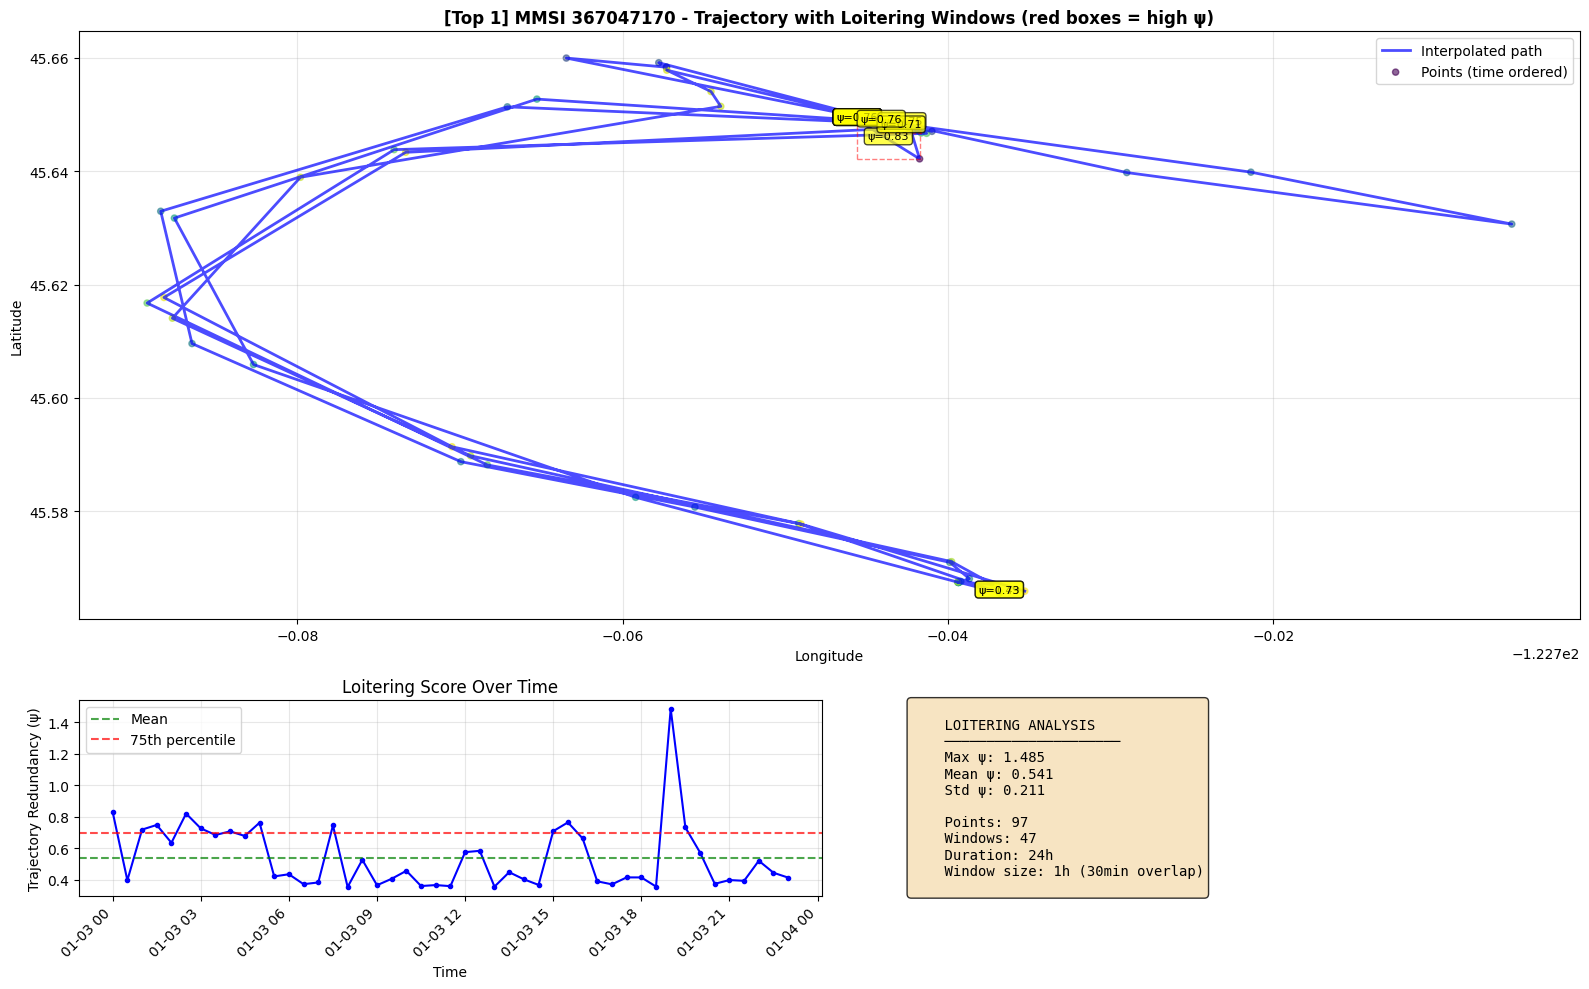

Vessel 2/10: MMSI 316018616 | max_ψ=1.469 | mean_ψ=0.653


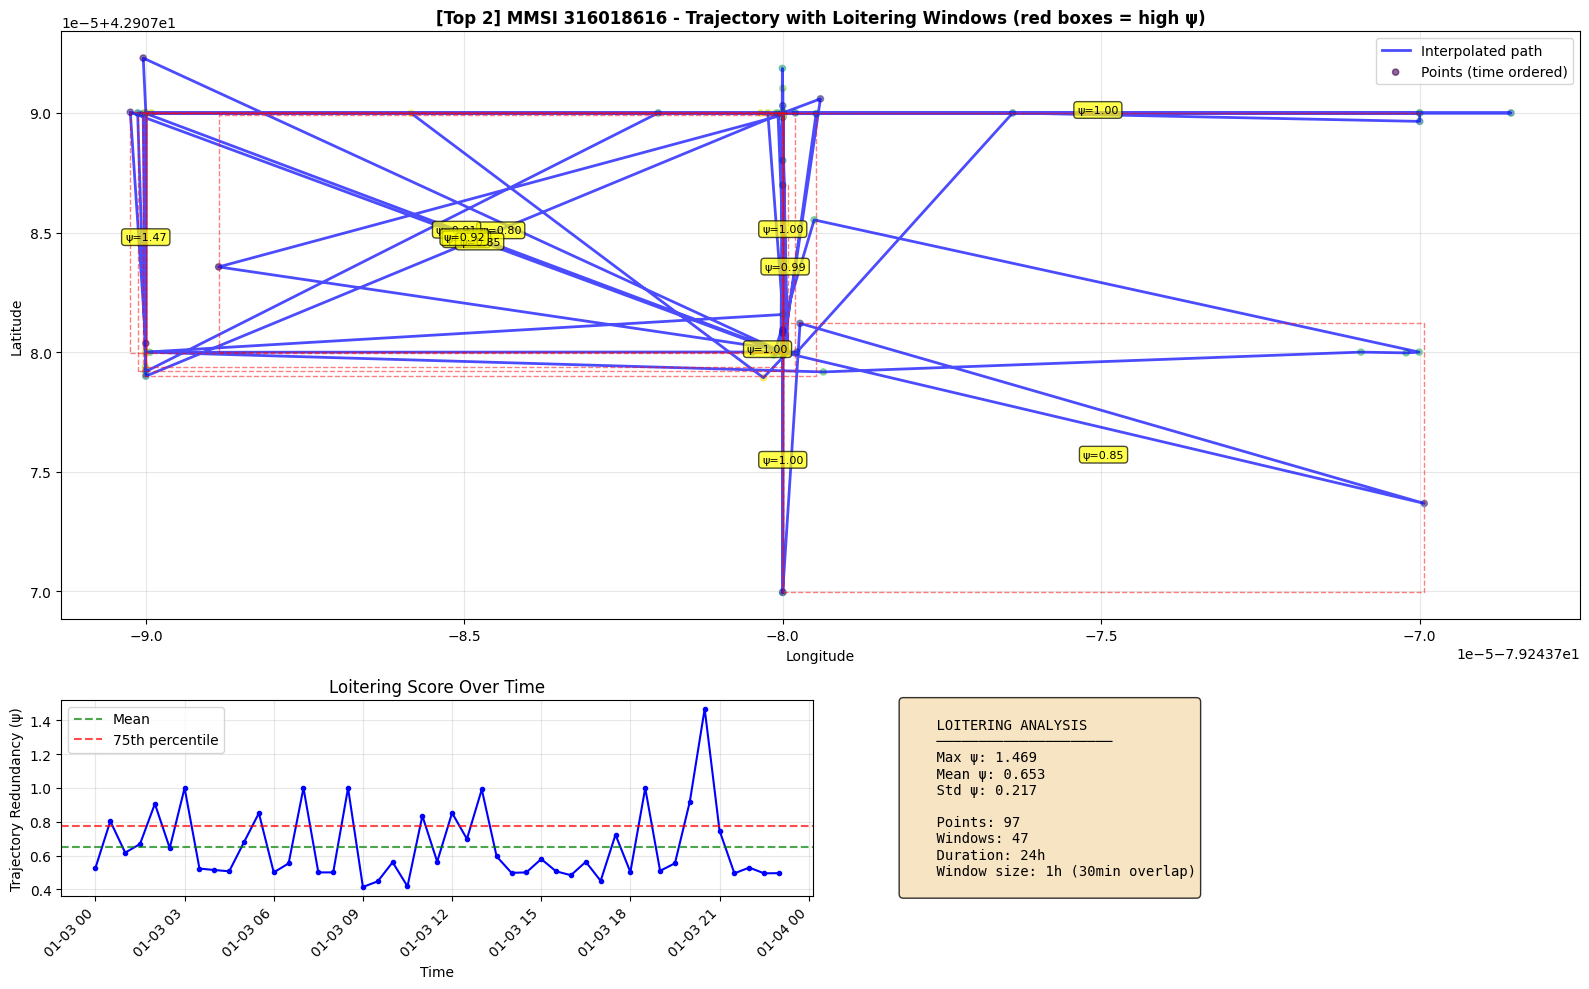

Vessel 3/10: MMSI 367413000 | max_ψ=1.460 | mean_ψ=0.436


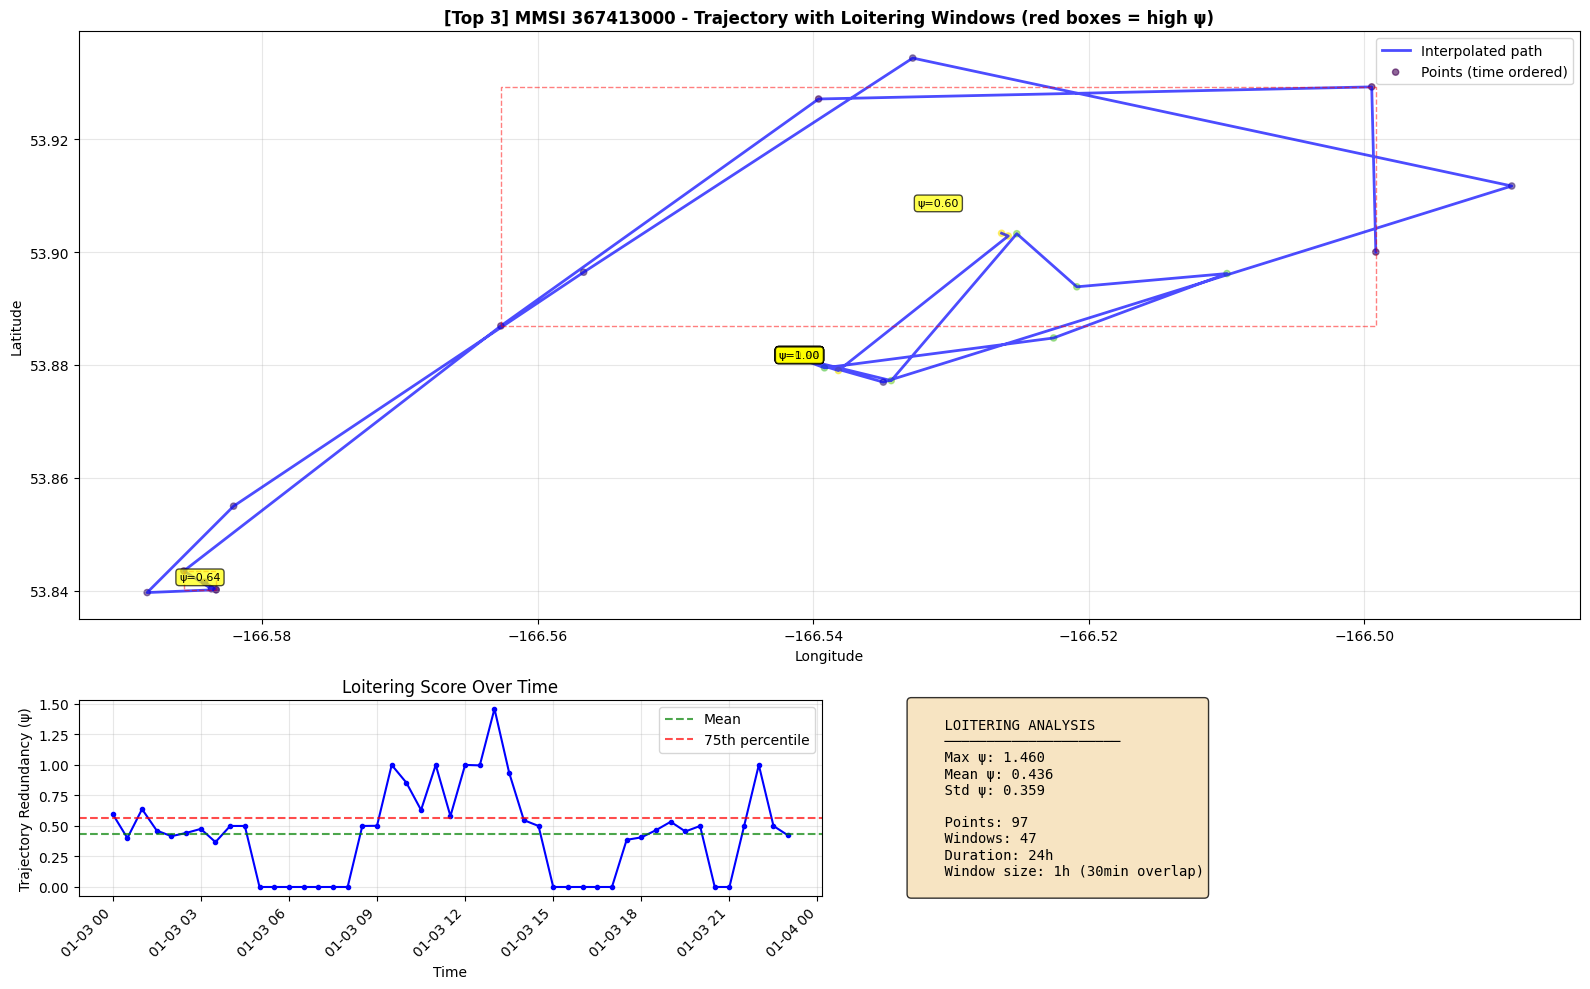

Vessel 4/10: MMSI 367318570 | max_ψ=1.441 | mean_ψ=0.645


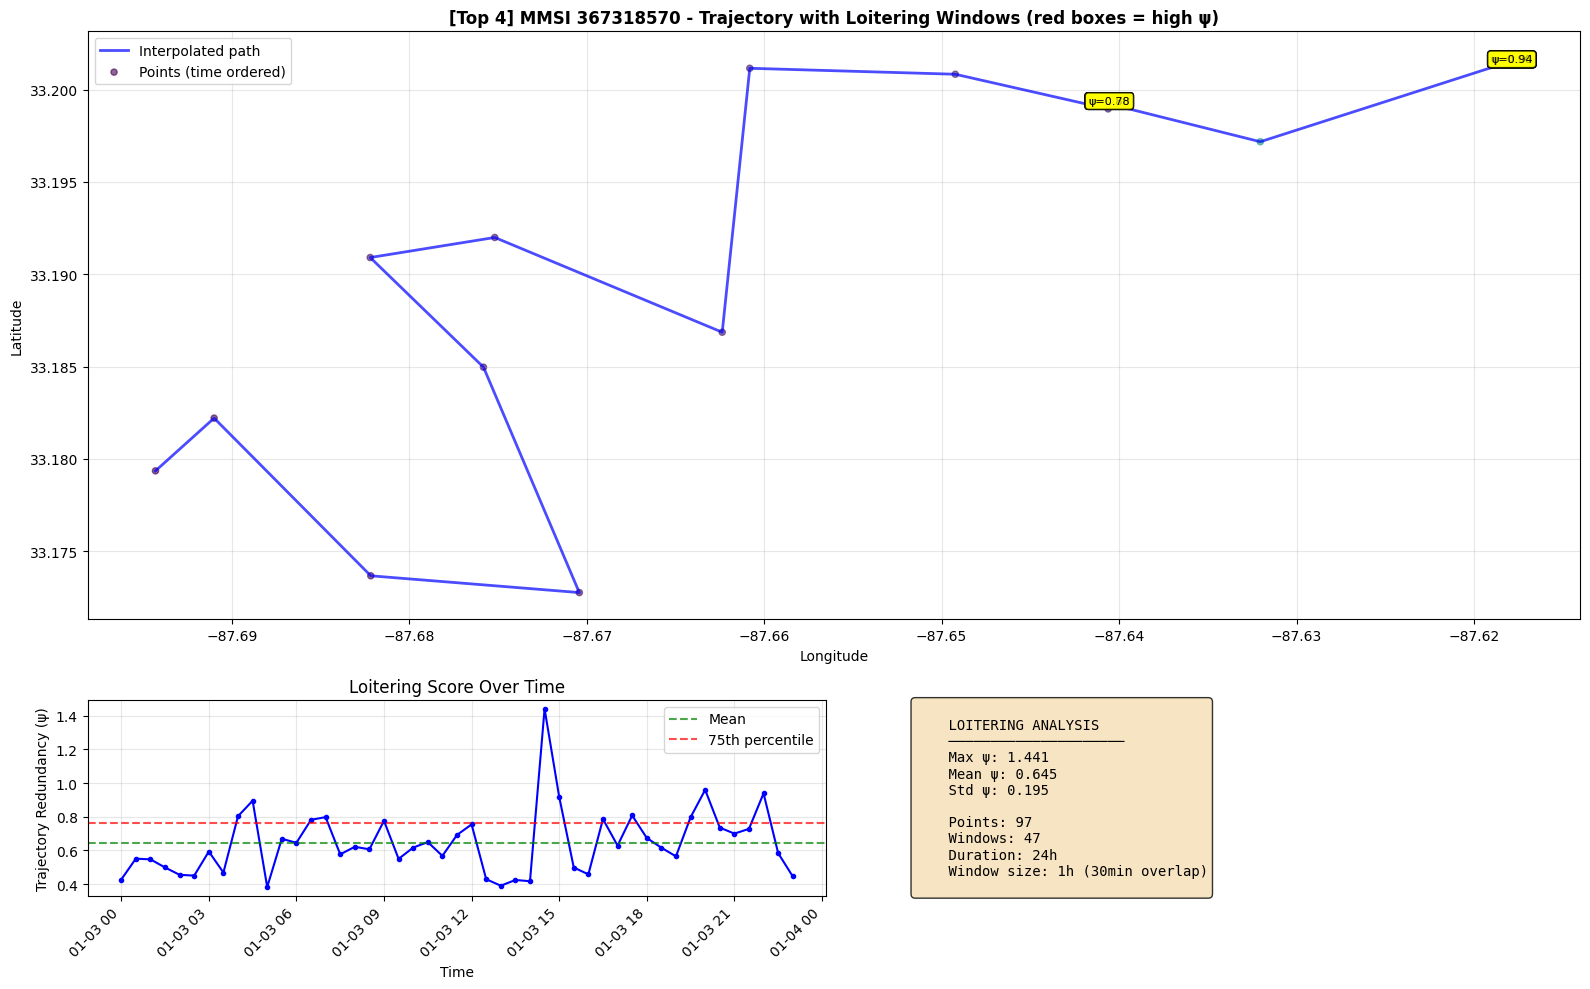

Vessel 5/10: MMSI 366999519 | max_ψ=1.422 | mean_ψ=0.590


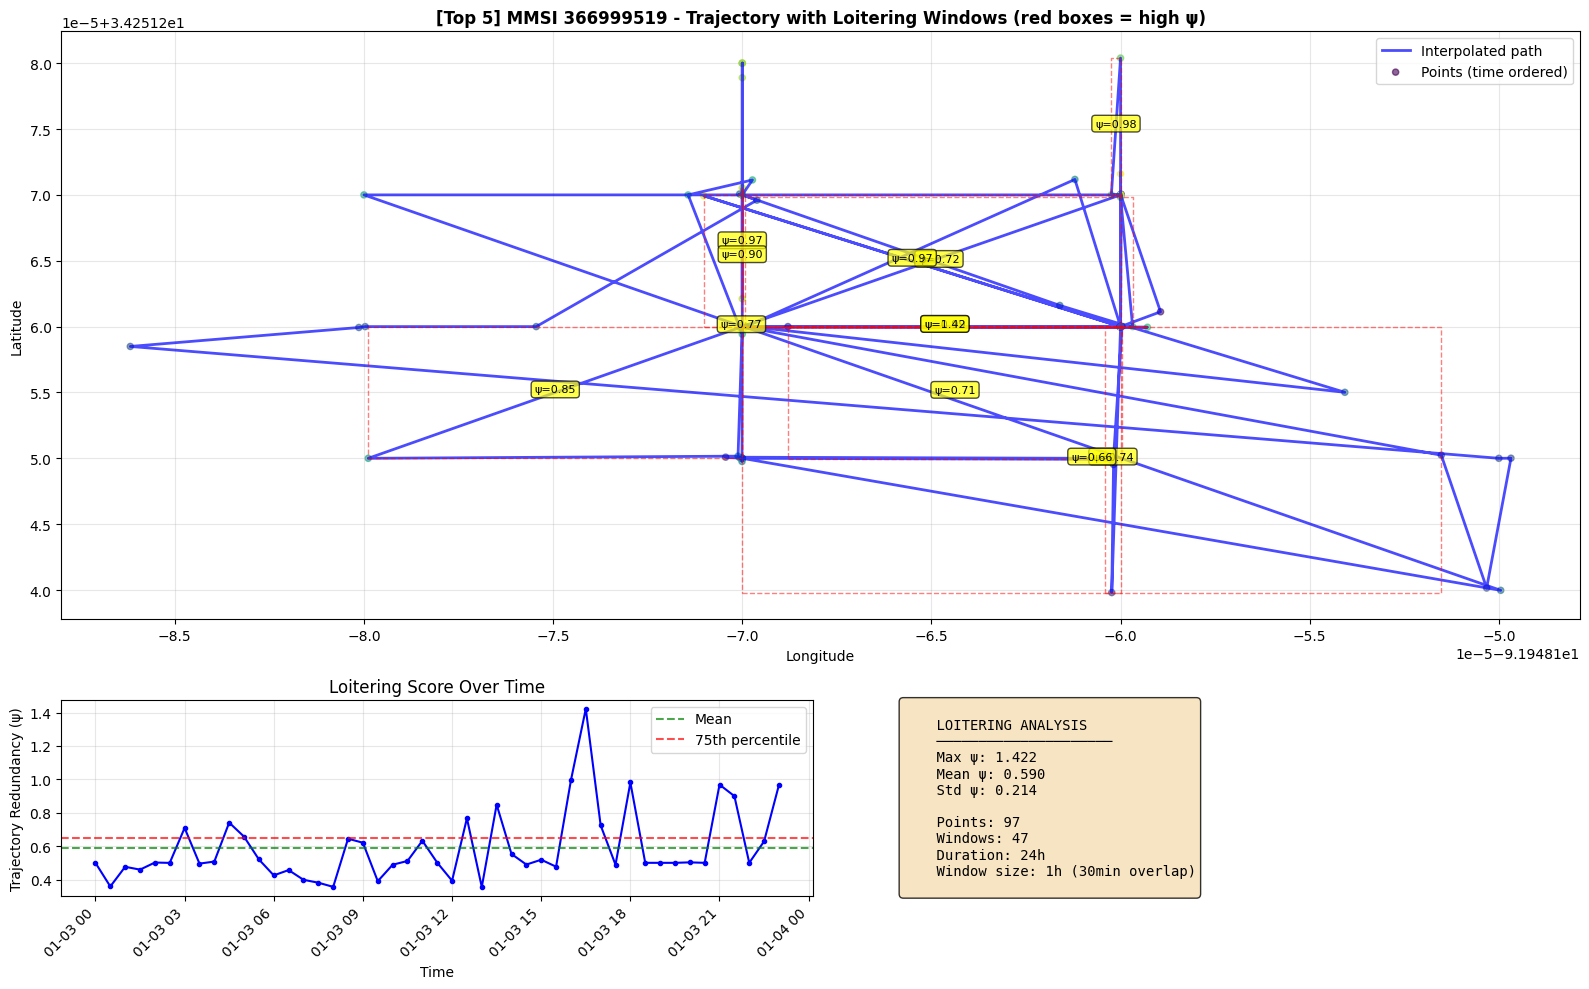

Vessel 6/10: MMSI 367699890 | max_ψ=1.411 | mean_ψ=0.575


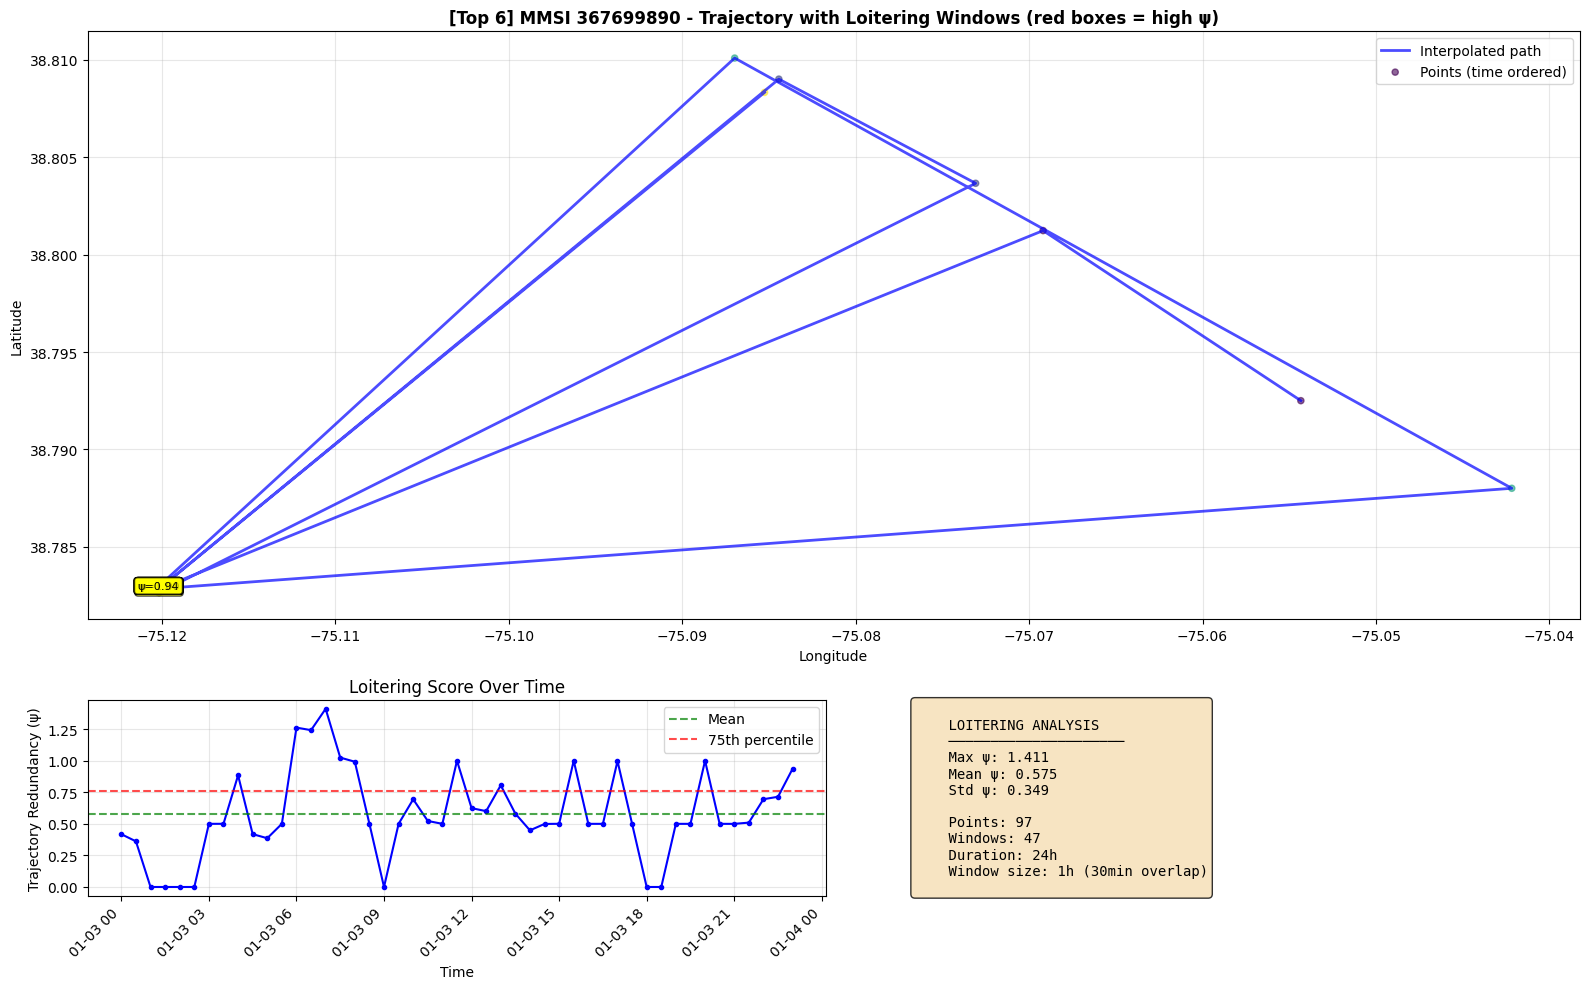

Vessel 7/10: MMSI 367098310 | max_ψ=1.397 | mean_ψ=0.662


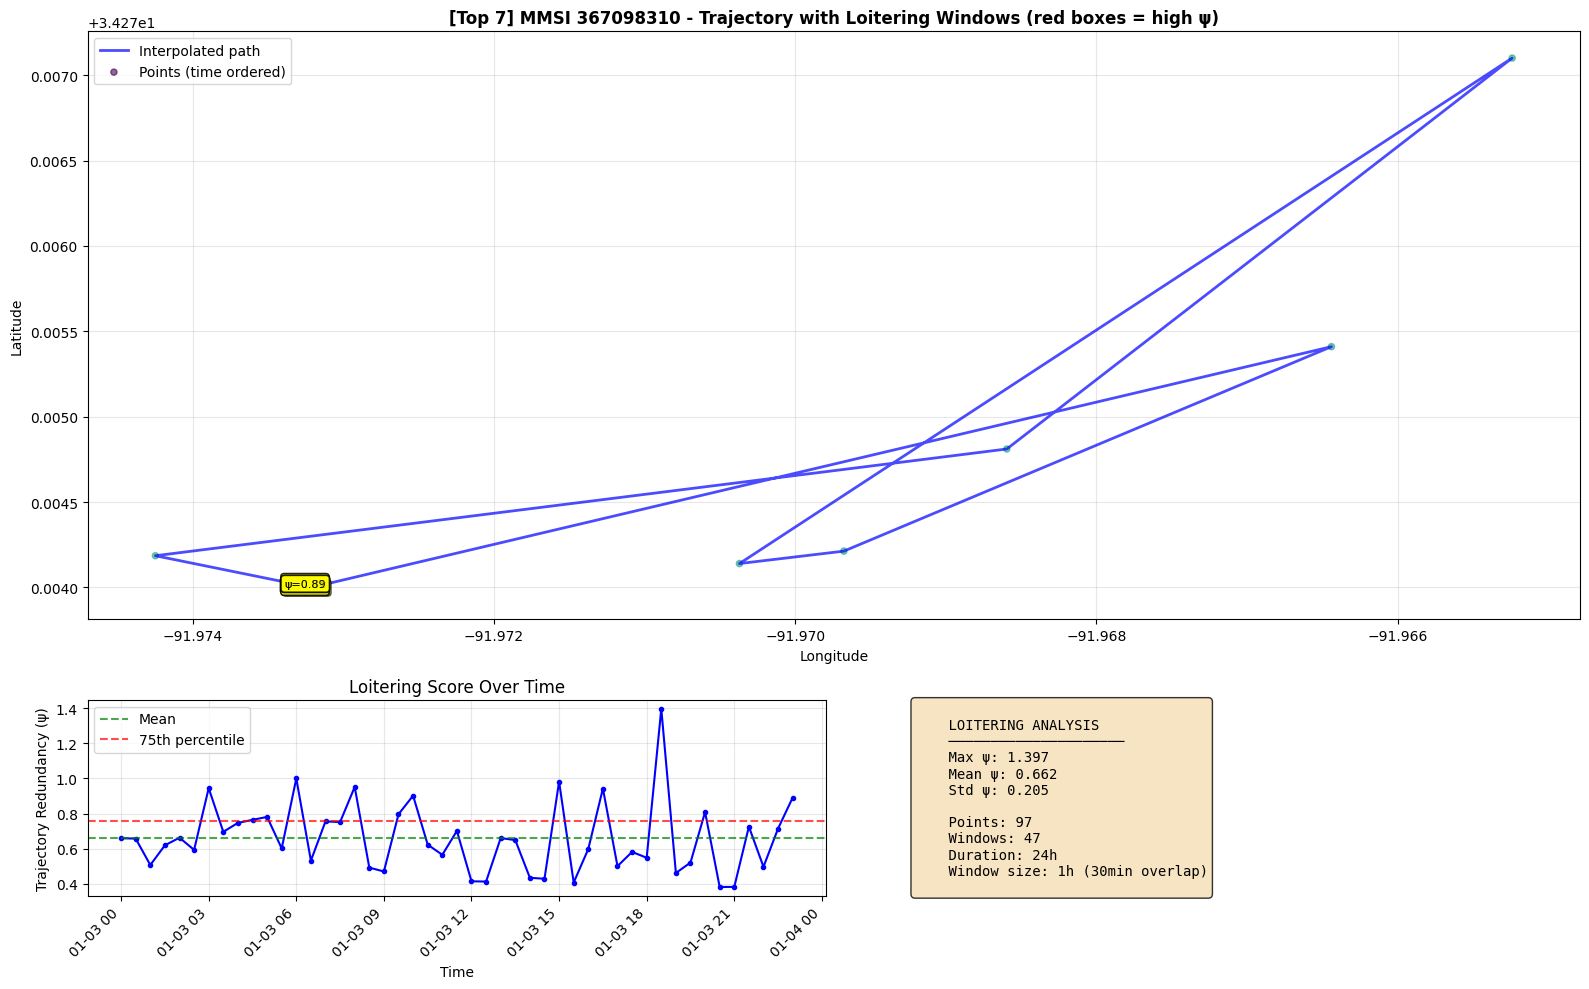

Vessel 8/10: MMSI 316206000 | max_ψ=1.386 | mean_ψ=0.640


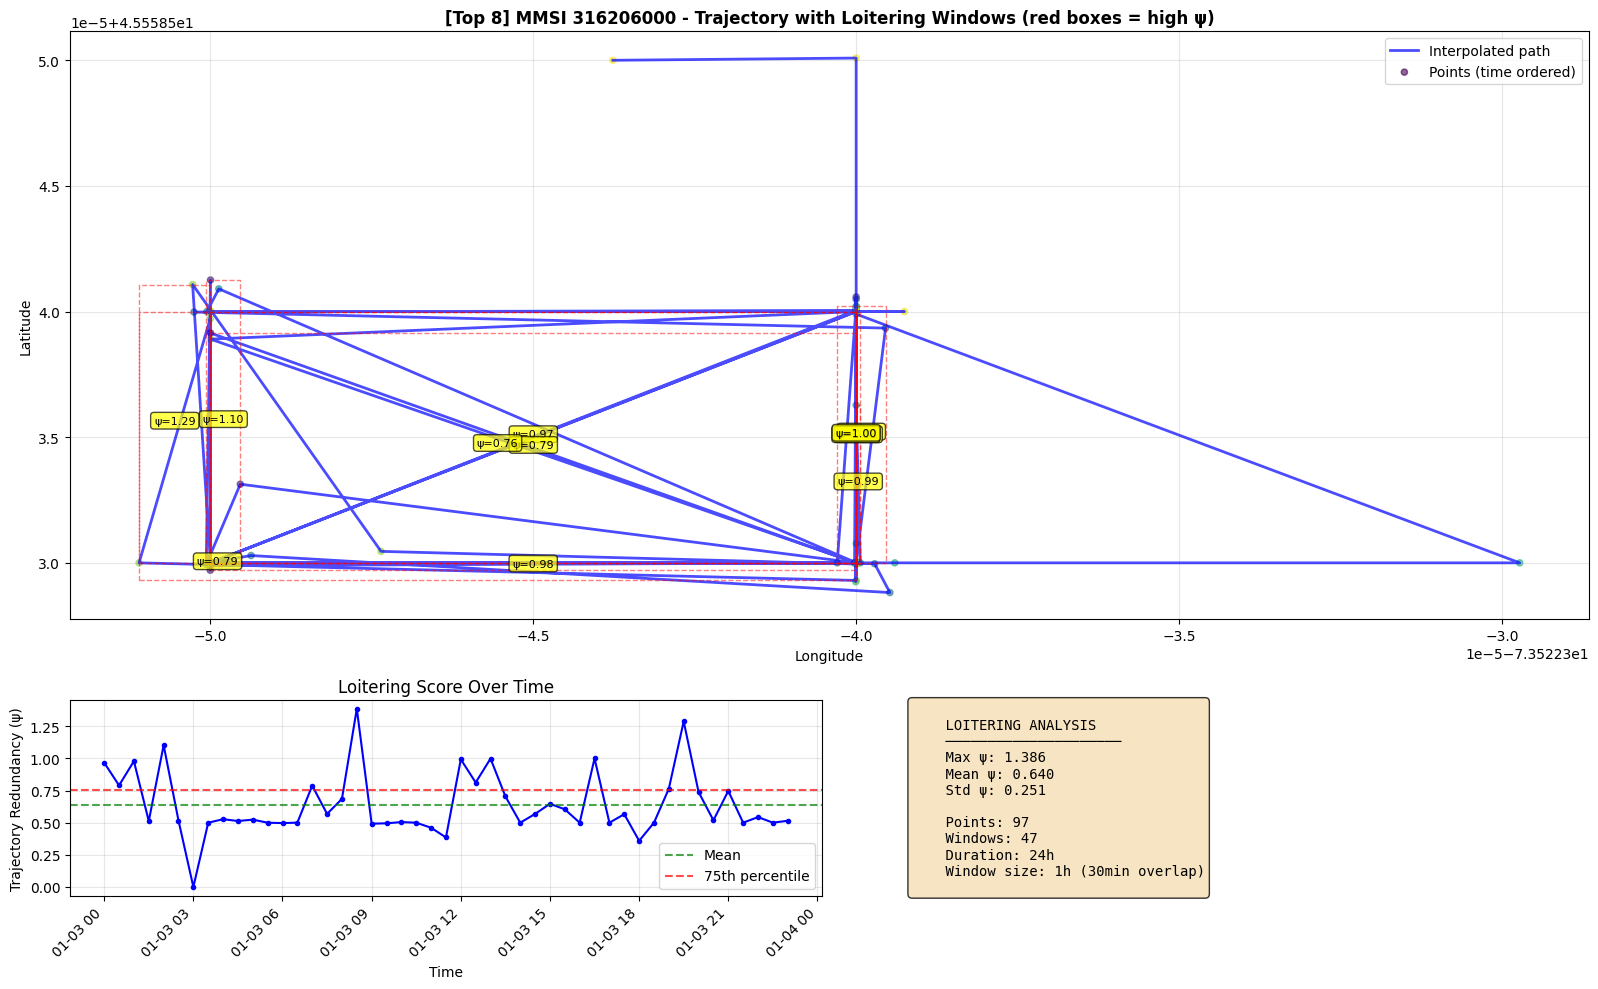

Vessel 9/10: MMSI 367082430 | max_ψ=1.367 | mean_ψ=0.543


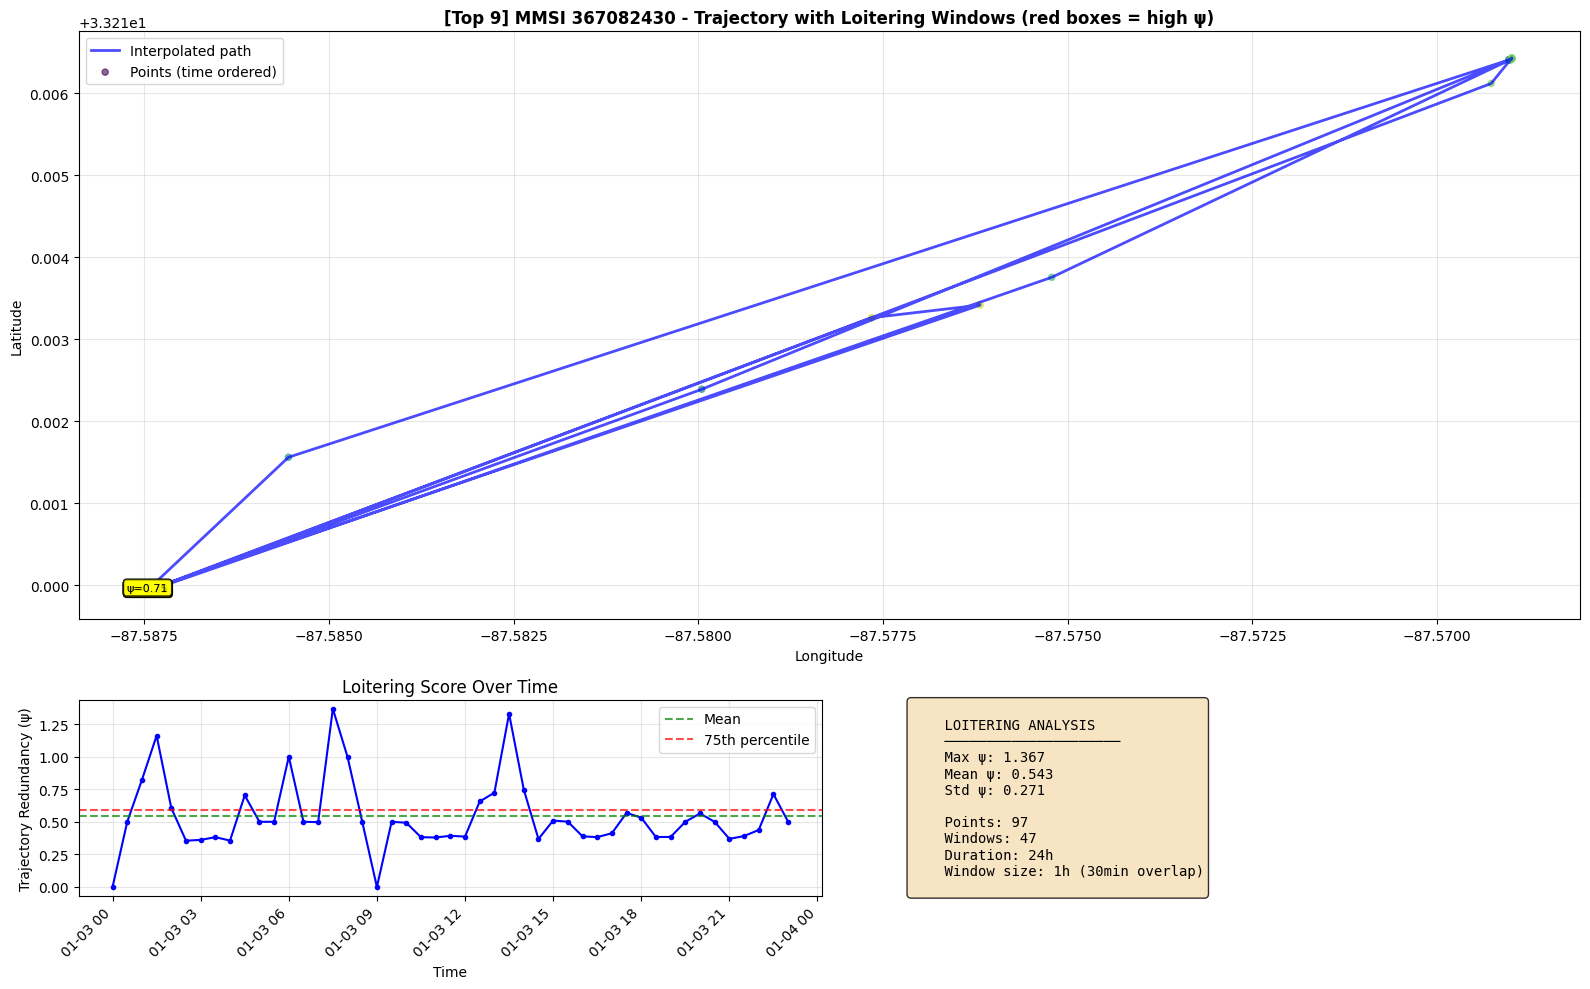

Vessel 10/10: MMSI 565034000 | max_ψ=1.343 | mean_ψ=0.549


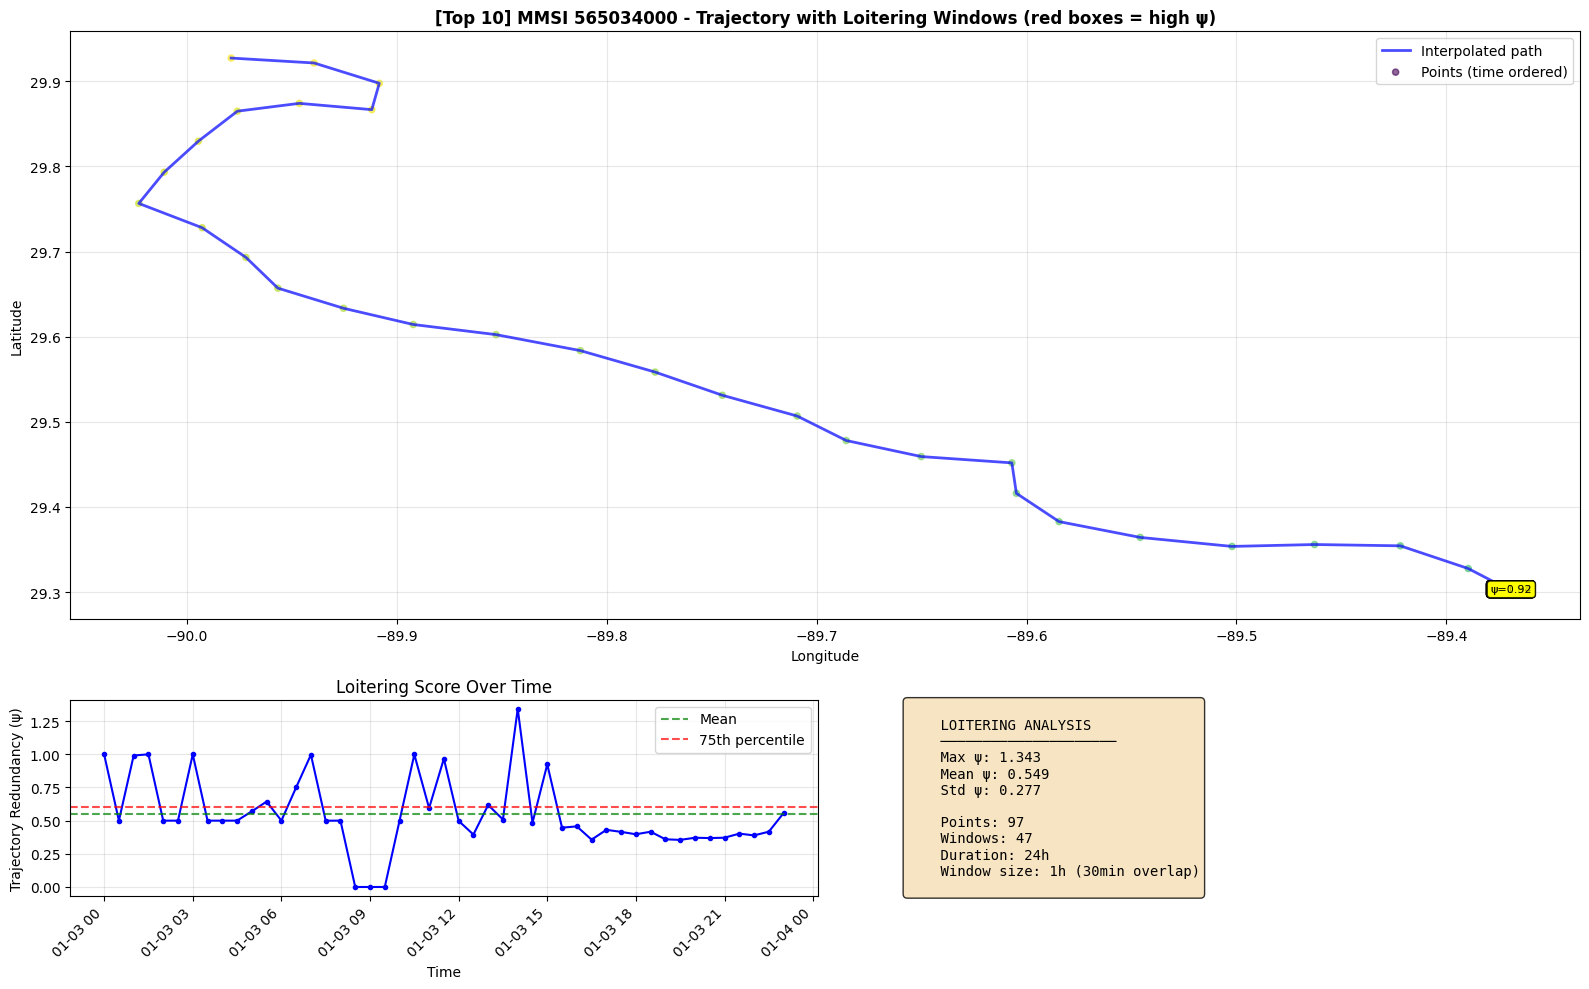

In [ ]:
# ==================== VISUALIZE TOP LOITERING VESSELS ====================


def plot_vessel_loitering_analysis(
    mmsi,
    original_traj,
    interpolated_traj,
    loitering_scores_df,
    title_prefix="",
    figsize=(16, 10),
):
    """
    Visualize vessel trajectory with loitering windows and scores.

    Shows:
    - Left: Interpolated trajectory with sliding windows as colored rectangles
    - Right: Loitering score (ψ) over time
    """
    if len(interpolated_traj) < 2:
        return

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 2, height_ratios=[3, 1], width_ratios=[1, 1])

    # Main trajectory plot
    ax_traj = fig.add_subplot(gs[0, :])

    # Extract lat/lon for interpolated trajectory
    lat = interpolated_traj["lat"].values
    lon = interpolated_traj["lon"].values

    # Plot trajectory
    ax_traj.plot(lon, lat, "b-", linewidth=2, alpha=0.7, label="Interpolated path")
    ax_traj.scatter(
        lon,
        lat,
        c=range(len(lat)),
        cmap="viridis",
        s=20,
        alpha=0.6,
        label="Points (time ordered)",
    )

    # Plot bounding box for each high-score window
    high_score_windows = loitering_scores_df[
        loitering_scores_df["psi"] > loitering_scores_df["psi"].quantile(0.75)
    ]

    for idx, (_, window_row) in enumerate(high_score_windows.iterrows()):
        t_start = window_row["window_start"]
        t_end = window_row["window_end"]
        psi = window_row["psi"]

        # Get points in window
        mask = (interpolated_traj["timestamp"] >= t_start) & (
            interpolated_traj["timestamp"] < t_end
        )
        window_traj = interpolated_traj[mask]

        if len(window_traj) > 0:
            min_lat, max_lat = window_traj["lat"].min(), window_traj["lat"].max()
            min_lon, max_lon = window_traj["lon"].min(), window_traj["lon"].max()

            # Draw bounding box
            rect_lon = [min_lon, max_lon, max_lon, min_lon, min_lon]
            rect_lat = [min_lat, min_lat, max_lat, max_lat, min_lat]
            ax_traj.plot(rect_lon, rect_lat, "r--", alpha=0.5, linewidth=1)

            # Annotate with psi value
            ax_traj.text(
                (min_lon + max_lon) / 2,
                (min_lat + max_lat) / 2,
                f"ψ={psi:.2f}",
                fontsize=8,
                ha="center",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7),
            )

    ax_traj.set_xlabel("Longitude")
    ax_traj.set_ylabel("Latitude")
    ax_traj.set_title(
        f"{title_prefix}MMSI {mmsi} - Trajectory with Loitering Windows (red boxes = high ψ)",
        fontsize=12,
        fontweight="bold",
    )
    ax_traj.legend(loc="best")
    ax_traj.grid(True, alpha=0.3)

    # Loitering score time series
    ax_score = fig.add_subplot(gs[1, 0])
    ax_score.plot(
        loitering_scores_df["window_start"],
        loitering_scores_df["psi"],
        "b-",
        marker="o",
        markersize=3,
    )
    ax_score.axhline(
        loitering_scores_df["psi"].mean(),
        color="g",
        linestyle="--",
        label="Mean",
        alpha=0.7,
    )
    ax_score.axhline(
        loitering_scores_df["psi"].quantile(0.75),
        color="r",
        linestyle="--",
        label="75th percentile",
        alpha=0.7,
    )
    ax_score.set_xlabel("Time")
    ax_score.set_ylabel("Trajectory Redundancy (ψ)")
    ax_score.set_title("Loitering Score Over Time")
    ax_score.legend()
    ax_score.grid(True, alpha=0.3)
    plt.setp(ax_score.xaxis.get_majorticklabels(), rotation=45, ha="right")

    # Statistics box
    ax_stats = fig.add_subplot(gs[1, 1])
    ax_stats.axis("off")

    stats_text = f"""
    LOITERING ANALYSIS
    ─────────────────────
    Max ψ: {loitering_scores_df['psi'].max():.3f}
    Mean ψ: {loitering_scores_df['psi'].mean():.3f}
    Std ψ: {loitering_scores_df['psi'].std():.3f}
    
    Points: {len(interpolated_traj)}
    Windows: {len(loitering_scores_df)}
    Duration: 24h
    Window size: 1h (30min overlap)
    """

    ax_stats.text(
        0.1,
        0.5,
        stats_text,
        fontsize=10,
        family="monospace",
        verticalalignment="center",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
    )

    plt.tight_layout()
    plt.show()


def visualize_top_loitering_vessels(
    loitering_metrics, loitering_details, interpolated_dict, num_vessels=10
):
    """
    Visualize the top N vessels with highest loitering scores.
    """
    top_vessels = loitering_metrics.head(num_vessels)

    print(f"\n{'='*80}")
    print(f"VISUALIZING TOP {num_vessels} LOITERING VESSELS")
    print(f"{'='*80}\n")

    for idx, (mmsi_idx, row) in enumerate(top_vessels.iterrows(), 1):
        mmsi = int(row["MMSI"])
        max_psi = row["max_psi"]
        mean_psi = row["mean_psi"]

        if mmsi in interpolated_dict and mmsi in loitering_details:
            print(
                f"Vessel {idx}/10: MMSI {mmsi} | max_ψ={max_psi:.3f} | mean_ψ={mean_psi:.3f}"
            )

            plot_vessel_loitering_analysis(
                mmsi,
                None,  # original_traj not needed for interpolated
                interpolated_dict[mmsi],
                loitering_details[mmsi],
                title_prefix=f"[Top {idx}] ",
                figsize=(16, 10),
            )


# Visualize top 10 loitering vessels
visualize_top_loitering_vessels(
    loitering_metrics, loitering_details, loaded_data, num_vessels=35
)


LOITERING ANALYSIS SUMMARY REPORT

Dataset: January 3, 2020
Total Vessels Analyzed: 428
Sliding Window: 1 hour | Overlap: 30 minutes (50%)

Metrics Description:
  - MMSI: Maritime Mobile Service Identity (vessel ID)
  - max_psi: Maximum trajectory redundancy score in any window
  - mean_psi: Average trajectory redundancy across all windows
  - std_psi: Standard deviation of redundancy scores
  - num_points: Interpolated trajectory points (regular 5-min intervals)
  - num_windows: Number of 1-hour sliding windows analyzed
  - duration_hours: Total trajectory duration

────────────────────────────────────────────────────────────────────────────────
TRAJECTORY REDUNDANCY (ψ) INTERPRETATION
────────────────────────────────────────────────────────────────────────────────
  ψ = D / P  where:
    D = Total dynamic trajectory length (nautical miles)
    P = Perimeter of minimum bounding box

  HIGH ψ (>1.0): Loitering behavior detected
    - Vessel traces long path within small area
    - Ind

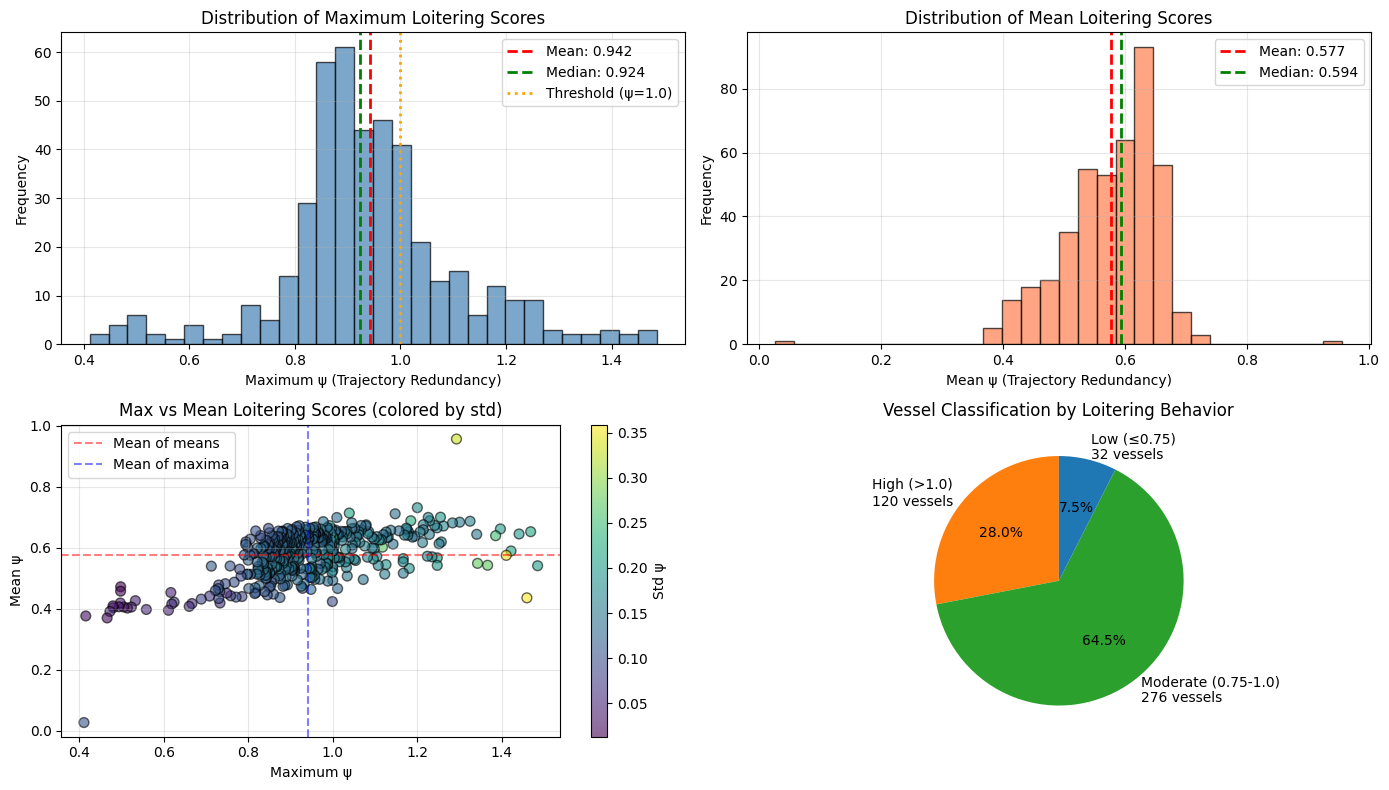

In [ ]:
# ==================== GENERATE LOITERING SUMMARY REPORT ====================


def generate_loitering_summary_report(loitering_metrics, output_dir):
    """
    Generate comprehensive loitering analysis summary report and save to CSV.
    """
    report_file = output_dir / "loitering_summary_2020_01_03.csv"

    # Save detailed metrics to CSV
    loitering_metrics.to_csv(report_file, index=False)

    print(f"\n{'='*80}")
    print("LOITERING ANALYSIS SUMMARY REPORT")
    print(f"{'='*80}")
    print(f"\nDataset: January 3, 2020")
    print(f"Total Vessels Analyzed: {len(loitering_metrics)}")
    print(f"Sliding Window: 1 hour | Overlap: 30 minutes (50%)")
    print(f"\nMetrics Description:")
    print(f"  - MMSI: Maritime Mobile Service Identity (vessel ID)")
    print(f"  - max_psi: Maximum trajectory redundancy score in any window")
    print(f"  - mean_psi: Average trajectory redundancy across all windows")
    print(f"  - std_psi: Standard deviation of redundancy scores")
    print(f"  - num_points: Interpolated trajectory points (regular 5-min intervals)")
    print(f"  - num_windows: Number of 1-hour sliding windows analyzed")
    print(f"  - duration_hours: Total trajectory duration")

    print(f"\n{'─'*80}")
    print("TRAJECTORY REDUNDANCY (ψ) INTERPRETATION")
    print(f"{'─'*80}")
    print(f"  ψ = D / P  where:")
    print(f"    D = Total dynamic trajectory length (nautical miles)")
    print(f"    P = Perimeter of minimum bounding box")
    print(f"\n  HIGH ψ (>1.0): Loitering behavior detected")
    print(f"    - Vessel traces long path within small area")
    print(f"    - Indicates: Patrol, survey, or waiting pattern")
    print(f"\n  LOW ψ (<0.5): Direct transit")
    print(f"    - Vessel moves efficiently point-to-point")
    print(f"    - Minimal path redundancy")

    print(f"\n{'─'*80}")
    print("STATISTICAL SUMMARY")
    print(f"{'─'*80}")
    print(f"\nmax_psi statistics:")
    print(f"  Mean:    {loitering_metrics['max_psi'].mean():.4f}")
    print(f"  Median:  {loitering_metrics['max_psi'].median():.4f}")
    print(f"  Std:     {loitering_metrics['max_psi'].std():.4f}")
    print(f"  Min:     {loitering_metrics['max_psi'].min():.4f}")
    print(f"  Max:     {loitering_metrics['max_psi'].max():.4f}")
    print(f"  Q1:      {loitering_metrics['max_psi'].quantile(0.25):.4f}")
    print(f"  Q3:      {loitering_metrics['max_psi'].quantile(0.75):.4f}")

    print(f"\nmean_psi statistics:")
    print(f"  Mean:    {loitering_metrics['mean_psi'].mean():.4f}")
    print(f"  Median:  {loitering_metrics['mean_psi'].median():.4f}")
    print(f"  Std:     {loitering_metrics['mean_psi'].std():.4f}")
    print(f"  Min:     {loitering_metrics['mean_psi'].min():.4f}")
    print(f"  Max:     {loitering_metrics['mean_psi'].max():.4f}")

    # Loitering classification
    high_loiter = (loitering_metrics["max_psi"] > 1.0).sum()
    moderate_loiter = (
        (loitering_metrics["max_psi"] > 0.75) & (loitering_metrics["max_psi"] <= 1.0)
    ).sum()
    low_loiter = (loitering_metrics["max_psi"] <= 0.75).sum()

    print(f"\n{'─'*80}")
    print("LOITERING CLASSIFICATION (based on max_psi)")
    print(f"{'─'*80}")
    print(
        f"  High Loitering (max_psi > 1.0):     {high_loiter:4d} vessels ({high_loiter/len(loitering_metrics)*100:5.1f}%)"
    )
    print(
        f"  Moderate Loitering (0.75-1.0):     {moderate_loiter:4d} vessels ({moderate_loiter/len(loitering_metrics)*100:5.1f}%)"
    )
    print(
        f"  Low Loitering (max_psi ≤ 0.75):    {low_loiter:4d} vessels ({low_loiter/len(loitering_metrics)*100:5.1f}%)"
    )

    print(f"\n{'─'*80}")
    print("TOP 20 LOITERING VESSELS")
    print(f"{'─'*80}")
    top_20 = loitering_metrics.head(20)[
        ["MMSI", "max_psi", "mean_psi", "num_points", "duration_hours"]
    ]
    print(top_20.to_string(index=False))

    print(f"\n{'─'*80}")
    print(f"✅ Report saved to: {report_file}")
    print(f"{'─'*80}\n")


def create_loitering_distribution_plot(loitering_metrics, figsize=(14, 8)):
    """
    Create distribution plots for loitering metrics.
    """
    fig, axes = plt.subplots(2, 2, figsize=figsize)

    # Max psi distribution
    ax = axes[0, 0]
    ax.hist(
        loitering_metrics["max_psi"],
        bins=30,
        color="steelblue",
        alpha=0.7,
        edgecolor="black",
    )
    ax.axvline(
        loitering_metrics["max_psi"].mean(),
        color="red",
        linestyle="--",
        linewidth=2,
        label=f'Mean: {loitering_metrics["max_psi"].mean():.3f}',
    )
    ax.axvline(
        loitering_metrics["max_psi"].median(),
        color="green",
        linestyle="--",
        linewidth=2,
        label=f'Median: {loitering_metrics["max_psi"].median():.3f}',
    )
    ax.axvline(
        1.0, color="orange", linestyle=":", linewidth=2, label="Threshold (ψ=1.0)"
    )
    ax.set_xlabel("Maximum ψ (Trajectory Redundancy)")
    ax.set_ylabel("Frequency")
    ax.set_title("Distribution of Maximum Loitering Scores")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Mean psi distribution
    ax = axes[0, 1]
    ax.hist(
        loitering_metrics["mean_psi"],
        bins=30,
        color="coral",
        alpha=0.7,
        edgecolor="black",
    )
    ax.axvline(
        loitering_metrics["mean_psi"].mean(),
        color="red",
        linestyle="--",
        linewidth=2,
        label=f'Mean: {loitering_metrics["mean_psi"].mean():.3f}',
    )
    ax.axvline(
        loitering_metrics["mean_psi"].median(),
        color="green",
        linestyle="--",
        linewidth=2,
        label=f'Median: {loitering_metrics["mean_psi"].median():.3f}',
    )
    ax.set_xlabel("Mean ψ (Trajectory Redundancy)")
    ax.set_ylabel("Frequency")
    ax.set_title("Distribution of Mean Loitering Scores")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Max vs Mean scatter
    ax = axes[1, 0]
    scatter = ax.scatter(
        loitering_metrics["max_psi"],
        loitering_metrics["mean_psi"],
        c=loitering_metrics["std_psi"],
        cmap="viridis",
        s=50,
        alpha=0.6,
        edgecolor="black",
    )
    ax.axhline(
        loitering_metrics["mean_psi"].mean(),
        color="red",
        linestyle="--",
        alpha=0.5,
        label="Mean of means",
    )
    ax.axvline(
        loitering_metrics["max_psi"].mean(),
        color="blue",
        linestyle="--",
        alpha=0.5,
        label="Mean of maxima",
    )
    ax.set_xlabel("Maximum ψ")
    ax.set_ylabel("Mean ψ")
    ax.set_title("Max vs Mean Loitering Scores (colored by std)")
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("Std ψ")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Classification pie chart
    ax = axes[1, 1]
    high_loiter = (loitering_metrics["max_psi"] > 1.0).sum()
    moderate_loiter = (
        (loitering_metrics["max_psi"] > 0.75) & (loitering_metrics["max_psi"] <= 1.0)
    ).sum()
    low_loiter = (loitering_metrics["max_psi"] <= 0.75).sum()

    sizes = [high_loiter, moderate_loiter, low_loiter]
    labels = [
        f"High (>1.0)\n{high_loiter} vessels",
        f"Moderate (0.75-1.0)\n{moderate_loiter} vessels",
        f"Low (≤0.75)\n{low_loiter} vessels",
    ]
    colors = ["#ff7f0e", "#2ca02c", "#1f77b4"]

    ax.pie(sizes, labels=labels, colors=colors, autopct="%1.1f%%", startangle=90)
    ax.set_title("Vessel Classification by Loitering Behavior")

    plt.tight_layout()
    plt.show()


# Generate comprehensive report
generate_loitering_summary_report(loitering_metrics, output_dir)

# Create distribution visualization
create_loitering_distribution_plot(loitering_metrics)